# **Credit Card Fraud Detection: A Machine Learning Study on Highly Imbalanced Data**

## **Executive Summary**

Credit card fraud detection represents one of the most challenging applications of machine learning due to the extreme rarity of fraudulent transactions and the significant financial consequences associated with misclassification.

This notebook develops and evaluates a fraud detection framework using the European Credit Card Transactions dataset. The primary focus is the development of robust classification strategies for highly imbalanced data, where fraudulent transactions account for less than 0.2% of all observations.

The study emphasizes rigorous data quality assessment, exploratory analysis, baseline model development, threshold optimization, and imbalance-aware learning techniques.

---

## **Dataset Overview**

The dataset contains anonymized credit card transactions collected over a two-day period.

| Metric                       | Value                    |
| ---------------------------- | ------------------------ |
| Total Transactions           | 284,807                  |
| Features                     | 30 Predictors + 1 Target |
| Fraudulent Transactions      | 492                      |
| Legitimate Transactions      | 284,315                  |
| Initial Fraud Rate           | 0.1727%                  |
| Duplicate Records Identified | 1,081                    |

Following duplicate removal:

| Metric                  | Value   |
| ----------------------- | ------- |
| Final Dataset Size      | 283,726 |
| Fraudulent Transactions | 473     |
| Legitimate Transactions | 283,253 |
| Fraud Rate              | 0.1667% |

---

## **Problem Statement**

Fraud detection presents a unique modeling challenge due to severe class imbalance.

A classifier that predicts every transaction as legitimate would achieve approximately 99.83% accuracy while failing to identify a single fraudulent transaction.

Consequently, accuracy is an inadequate performance metric for this problem.

Instead, model evaluation focuses on metrics that better reflect minority-class detection performance:

* Precision
* Recall
* F1 Score
* ROC-AUC
* PR-AUC
* Threshold-Specific Performance

---

## **Objectives of This Study**

The objectives of this notebook are:

1. Assess the quality and integrity of the dataset.
2. Investigate the extent and implications of class imbalance.
3. Develop a reproducible baseline machine learning pipeline.
4. Examine the impact of probability threshold selection.
5. Evaluate imbalance-aware learning strategies.
6. Establish reliable benchmarks for fraud detection performance.

---

## **Methodological Framework**

The analysis follows a structured machine learning workflow:

Data Quality Assessment

↓

Duplicate Record Investigation

↓

Exploratory Data Analysis

↓

Feature and Target Separation

↓

Stratified Train-Test Split

↓

Preprocessing Pipeline Construction

↓

Baseline Logistic Regression Model

↓

Threshold Optimization

↓

Cost-Sensitive Learning

↓

SMOTE-Based Resampling

↓

Performance Evaluation

---

## **Data Quality Assessment**

Prior to model development, the dataset is examined for:

* Missing values
* Duplicate observations
* Target distribution integrity
* Potential sources of data leakage

The analysis identifies 1,081 duplicate transactions, which are investigated and removed to ensure a more reliable evaluation process.

---

## **Exploratory Analysis**

The exploratory analysis focuses on:

* Fraud prevalence
* Transaction amount characteristics
* Temporal transaction patterns
* Distributional properties of key variables

Special attention is given to understanding the implications of extreme class imbalance and its effect on model evaluation.

---

## **Baseline Modeling Strategy**

A baseline Logistic Regression model is developed using a preprocessing pipeline built with:

* ColumnTransformer
* RobustScaler
* Stratified sampling procedures

Establishing a baseline is essential for quantifying the impact of subsequent imbalance-handling techniques and ensuring that performance improvements can be objectively measured.

---

## **Threshold Optimization**

Rather than relying solely on the default classification threshold of 0.50, this study evaluates model performance across multiple operating thresholds.

This analysis highlights the trade-offs between precision and recall and demonstrates how threshold selection can substantially influence fraud detection effectiveness.

---

## **Evaluation Framework**

Model performance is assessed using:

| Metric           | Purpose                              |
| ---------------- | ------------------------------------ |
| Precision        | Reliability of fraud alerts          |
| Recall           | Ability to identify fraud            |
| F1 Score         | Balance between precision and recall |
| ROC-AUC          | Overall ranking performance          |
| PR-AUC           | Minority-class detection capability  |
| Confusion Matrix | Detailed error analysis              |

Given the severe class imbalance, particular emphasis is placed on Recall, F1 Score, and PR-AUC.

---

## **Technologies Used**

* Python
* Pandas
* NumPy
* Scikit-Learn
* Imbalanced-Learn
* Matplotlib
* Seaborn

---

## **Study Goal**

The purpose of this notebook is not merely to construct a fraud classifier, but to demonstrate a rigorous and reproducible workflow for solving highly imbalanced classification problems while maintaining sound evaluation practices and minimizing data leakage.


# **Importing Required Libraries**

This section imports the libraries required for data manipulation, visualization, model development, and evaluation.

The project follows a structured machine learning workflow, beginning with exploratory data analysis before progressing toward model development and deployment.

In [1]:
# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

print("Libraries Imported Successfully")

Libraries Imported Successfully


# **Loading Dataset**

The first step in any machine learning project is loading and inspecting the dataset.

We will examine:

- Dataset dimensions
- Available features
- Data types
- Initial records

This provides a high-level understanding of the dataset before deeper analysis.

In [2]:
df = pd.read_csv("/kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud/creditcard.csv")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


# **Dataset Dimensions**

Understanding the size of the dataset helps estimate:

- Computational requirements
- Storage requirements
- Potential modeling complexity

We examine the number of observations and features available.

In [3]:
rows, cols = df.shape

print(f"Number of Rows    : {rows}")
print(f"Number of Columns : {cols}")

df.shape

Number of Rows    : 284807
Number of Columns : 31


(284807, 31)

# **Previewing the Dataset**

A quick inspection of the first few records helps verify:

- Successful loading
- Feature names
- Data formatting
- Target variable presence

In [4]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


# **Dataset Information**

Understanding data types is essential because machine learning algorithms often require specific preprocessing techniques depending on whether features are:

- Numerical
- Categorical
- Datetime

We also inspect memory usage and non-null counts.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

# **Statistical Summary**

Descriptive statistics provide insight into:

- Central tendency
- Spread
- Minimum and maximum values
- Potential anomalies

This serves as an initial diagnostic step before visualization.

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.175161e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.384974e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.094852e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,1.021879e-15,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.494498e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.620335e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.149614e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.414189e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


# **Missing Value Analysis**

Missing values can significantly affect model performance.

Before proceeding further, we verify whether the dataset contains any missing observations that may require imputation.

In [7]:
missing_values = df.isnull().sum()

missing_df = pd.DataFrame({
    "Feature": missing_values.index,
    "Missing Values": missing_values.values,
    "Percentage": (missing_values.values/len(df))*100
})

missing_df[missing_df["Missing Values"] > 0]

,Feature,Missing Values,Percentage


In [8]:
# No Missing Values in the Dataset

# **Duplicate Record Analysis**

Duplicate transactions can introduce bias into machine learning models and distort evaluation metrics.

We inspect whether duplicate observations exist within the dataset.

In [9]:
duplicates = df.duplicated().sum()

print(f"Number of Duplicate Rows: {duplicates}")

Number of Duplicate Rows: 1081


# **Target Variable Identification**

The target variable for this project is:

**Class**

Where:

- 0 → Legitimate Transaction
- 1 → Fraudulent Transaction

Understanding the distribution of the target variable is critical because fraud detection is inherently an imbalanced classification problem.

In [10]:
df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

# **Class Distribution Analysis**

Class imbalance is the primary challenge of this project.

In fraud detection datasets, legitimate transactions vastly outnumber fraudulent transactions.

A visual inspection of class distribution helps quantify the severity of the imbalance and motivates the use of specialized evaluation metrics and imbalance-handling techniques later in the project.

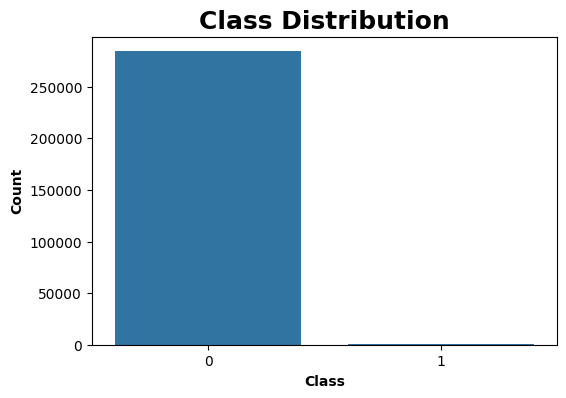

In [11]:
class_counts = df["Class"].value_counts()

plt.figure(figsize=(6,4))

sns.countplot(data=df,x="Class")

plt.title("Class Distribution",fontweight='bold',fontsize=18)
plt.xlabel("Class",fontweight='bold')
plt.ylabel("Count",fontweight='bold')

plt.show()

# **Fraud Prevalence**

Prevalence represents the proportion of fraudulent transactions within the dataset.

This quantity serves as an important reference point throughout the project, particularly when interpreting Precision-Recall curves and evaluating model performance.

In [12]:
fraud_percentage = (
    df["Class"].value_counts(normalize=True)[1]
)*100

non_fraud_percentage = (
    df["Class"].value_counts(normalize=True)[0]
)*100

print(f"Fraud Transactions     : {fraud_percentage:.4f}%")
print(f"Legitimate Transactions: {non_fraud_percentage:.4f}%")

Fraud Transactions     : 0.1727%
Legitimate Transactions: 99.8273%


# **Initial Data Quality Observations**

Based on the preliminary analysis, the following observations can be made:

### **Dataset Characteristics**

- The dataset contains **284,807 transactions** and **31 features**.
- All predictor variables are numerical.
- Features `V1` to `V28` are anonymized PCA-transformed components.
- The target variable is `Class`, where:
  - `0` → Legitimate Transaction
  - `1` → Fraudulent Transaction

---

### **Missing Values**

No missing values were detected in the dataset.

This eliminates the need for imputation strategies and simplifies the preprocessing pipeline.

---

### **Class Imbalance**

The dataset exhibits extreme class imbalance:

- Legitimate Transactions: **99.8273%**
- Fraudulent Transactions: **0.1727%**

This confirms that fraud detection is a highly imbalanced classification problem and that accuracy alone will not be an appropriate evaluation metric.

---

### **Duplicate Records**

A total of **1,081 duplicate transactions** were identified.

Duplicate records can potentially:

- Bias model learning
- Distort evaluation metrics
- Artificially inflate model performance

The impact of duplicate observations will be investigated before model development.

# **Investigating Duplicate Transactions**

Duplicate observations were detected during the data quality assessment phase.

Before removing them, it is important to understand:

- How many duplicate transactions belong to each class?
- Whether duplicates are predominantly legitimate or fraudulent transactions.
- Whether removing duplicates could unintentionally remove useful fraud patterns.

A data-driven decision will be made based on this analysis.

In [13]:
# Extract duplicate rows

duplicate_rows = df[df.duplicated()]

print(f"Number of Duplicate Rows: {duplicate_rows.shape[0]}")

duplicate_rows["Class"].value_counts()

Number of Duplicate Rows: 1081


Class
0    1062
1      19
Name: count, dtype: int64

In [14]:
duplicate_rows["Class"].value_counts(normalize=True)*100

Class
0    98.242368
1     1.757632
Name: proportion, dtype: float64

# **Decision on Duplicate Transactions**

The duplicate analysis revealed:

- Total Duplicate Records: **1,081**
- Legitimate Duplicates: **1,062**
- Fraudulent Duplicates: **19**

Interestingly, fraudulent transactions appear more frequently within the duplicate subset compared to their prevalence in the overall dataset.

However, duplicate observations may introduce information leakage and artificially inflate model performance by allowing identical records to appear multiple times during training and evaluation.

To ensure a cleaner and more realistic evaluation process, duplicate records will be removed before model development.

This approach is commonly adopted in fraud detection workflows and helps produce more reliable performance estimates.

In [15]:
df = df.drop_duplicates()

print("Shape After Removing Duplicates:")
print(df.shape)

Shape After Removing Duplicates:
(283726, 31)


In [16]:
print("Remaining Duplicate Rows:")
print(df.duplicated().sum())

Remaining Duplicate Rows:
0


In [17]:
# No duplicates now has remained!

# **Recomputing the Class Distribution and Fraud Percentage**

In [18]:
df["Class"].value_counts()

Class
0    283253
1       473
Name: count, dtype: int64

In [19]:
fraud_percentage = (
    df["Class"].value_counts(normalize=True)[1]
)*100

print(f"Fraud Percentage After Cleaning: {fraud_percentage:.4f}%")

Fraud Percentage After Cleaning: 0.1667%


# **Post-Cleaning Summary**

After removing duplicate observations:

- Dataset size reduced from **284,807** to **283,726** transactions.
- All duplicate records were successfully removed.
- The dataset remains highly imbalanced.
- Fraudulent transactions now represent only **0.1667%** of all observations.

The dataset is now considered sufficiently clean for exploratory data analysis and subsequent model development.

At this stage:

- Missing values have been addressed (none present).
- Duplicate records have been removed.
- Target distribution has been verified.

The next step is to perform exploratory data analysis to better understand transaction characteristics and identify patterns that may help distinguish fraudulent transactions from legitimate ones.

# **Transaction Amount Analysis**

Transaction amount is one of the few interpretable variables available in the dataset.

Understanding its distribution helps answer questions such as:

- Are fraudulent transactions generally larger?
- Are frauds concentrated in specific amount ranges?
- Is the feature heavily skewed?

These insights may influence preprocessing decisions later in the project.

In [20]:
df["Amount"].describe()

count    283726.000000
mean         88.472687
std         250.399437
min           0.000000
25%           5.600000
50%          22.000000
75%          77.510000
max       25691.160000
Name: Amount, dtype: float64

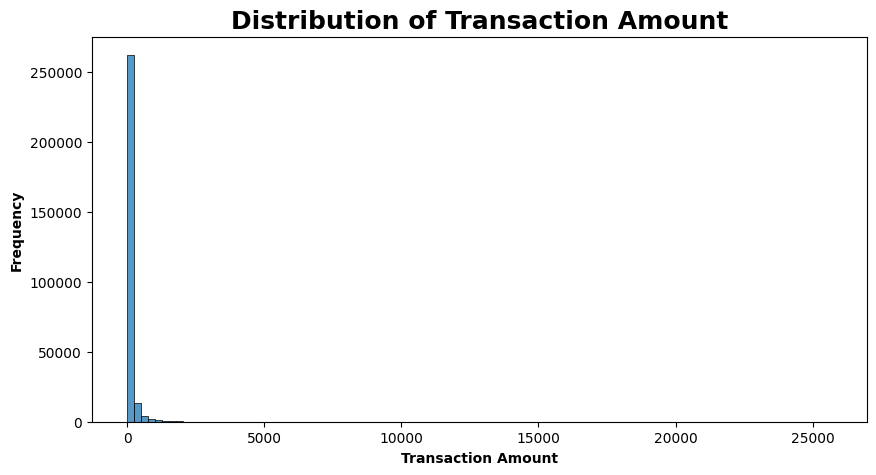

In [21]:
plt.figure(figsize=(10,5))

sns.histplot(df["Amount"],bins=100)

plt.title("Distribution of Transaction Amount",fontweight='bold',fontsize=18)
plt.xlabel("Transaction Amount",fontweight='bold')
plt.ylabel("Frequency",fontweight='bold')

plt.show()

# **Transaction Amount by Class**

To investigate whether fraudulent transactions exhibit different monetary characteristics, we compare transaction amounts across both classes.

Such differences can provide valuable predictive signals for machine learning models.

In [22]:
df.groupby("Class")["Amount"].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,283253.0,88.413575,250.379023,0.0,5.67,22.00,77.46,25691.16
1,473.0,123.871860,260.211041,0.0,1.00,9.82,105.89,2125.87


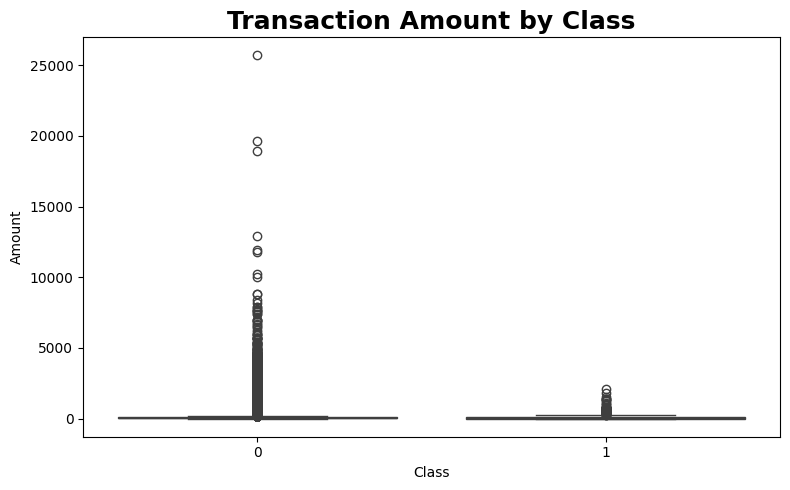

In [23]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df,x="Class",y="Amount")
plt.title("Transaction Amount by Class",fontweight='bold',fontsize=18)

plt.tight_layout()
plt.show()

# **Transaction Time Analysis**

The `Time` feature represents the elapsed time between a transaction and the first transaction recorded in the dataset.

Although it is not a direct timestamp, it may reveal temporal patterns associated with fraudulent activity.

We examine how transactions are distributed across the recorded time period.

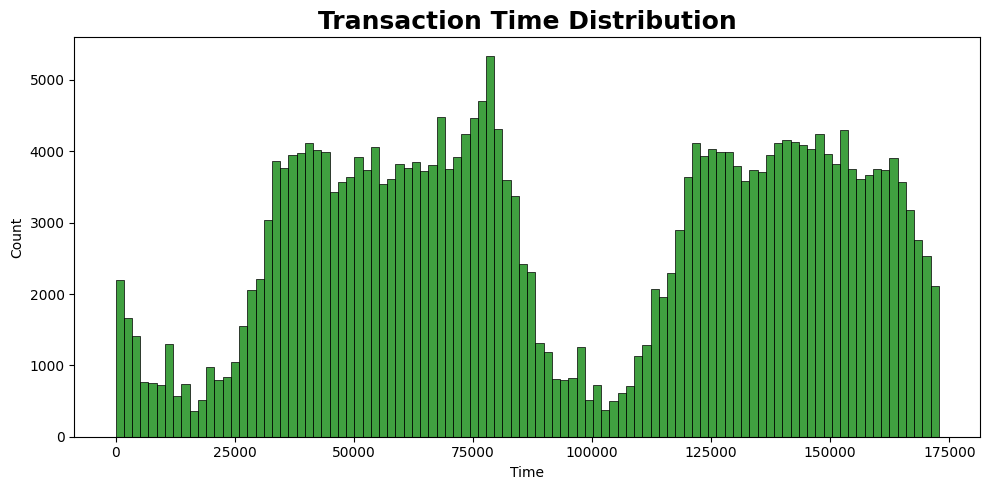

In [24]:
plt.figure(figsize=(10,5))

sns.histplot(df["Time"],bins=100,color='green')
plt.title("Transaction Time Distribution",fontweight='bold',fontsize=18)

plt.tight_layout()
plt.show()

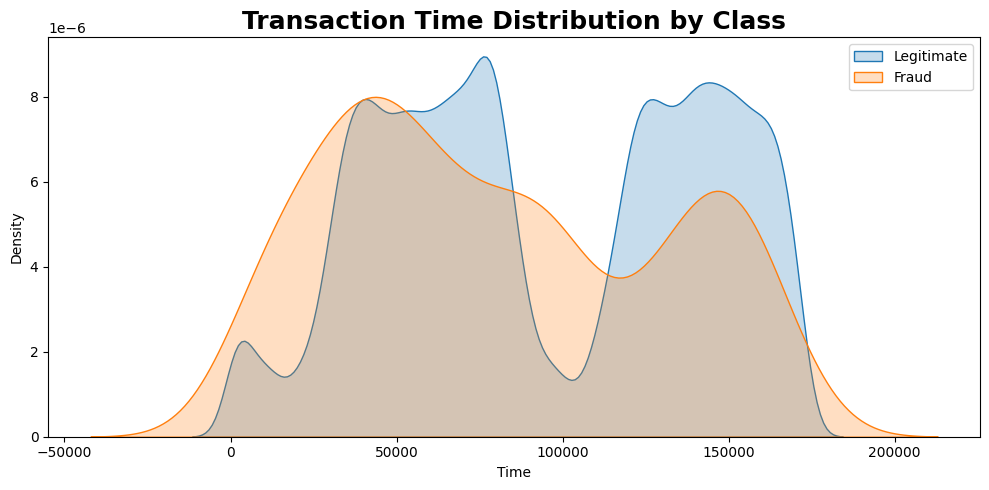

In [25]:
plt.figure(figsize=(10,5))

sns.kdeplot(data=df[df["Class"]==0],x="Time",label="Legitimate",fill=True)
sns.kdeplot(data=df[df["Class"]==1],x="Time",label="Fraud",fill=True)
plt.legend()
plt.title("Transaction Time Distribution by Class",fontweight='bold',fontsize=18)

plt.tight_layout()
plt.show()

# **Key Findings from Exploratory Data Analysis**

The exploratory analysis revealed several important characteristics of the dataset:

## **Extreme Class Imbalance**

- Fraudulent transactions account for only **0.1667%** of all observations.
- Legitimate transactions represent more than **99.8%** of the dataset.
- This confirms that fraud detection is a highly imbalanced classification problem.

---

## **Transaction Amount Characteristics**

- Transaction amounts exhibit a heavily right-skewed distribution.
- Most transactions involve relatively small amounts.
- A small number of extremely large transactions create significant outliers.
- Fraudulent transactions tend to have slightly higher average amounts than legitimate transactions, although substantial overlap exists.

---

## **Temporal Patterns**

- Transaction activity is not uniformly distributed across time.
- Fraudulent transactions appear to follow temporal patterns similar to legitimate transactions, but subtle differences are visible.
- The Time feature may still contain useful predictive information.

---

## **Implications for Modeling**

Several important modeling considerations arise from these observations:

- Accuracy will be an unreliable evaluation metric.
- Precision, Recall, F1-Score, ROC-AUC and especially PR-AUC will be emphasized.
- Proper handling of class imbalance will be required.
- The Amount feature contains extreme outliers and may require scaling.
- Data leakage must be avoided during preprocessing and resampling.

---

# **Transition to Model Development**

The dataset has now passed the following stages:

✅ Data Loading

✅ Data Inspection

✅ Missing Value Analysis

✅ Duplicate Removal

✅ Target Distribution Analysis

✅ Exploratory Data Analysis

The next phase focuses on preparing the data for machine learning by creating training and testing datasets while preserving the original class distribution.

# **Feature Selection and Data Splitting**

Machine learning models learn relationships between input features and the target variable.

Before training any model, we separate:

- **Features (X)** → information used to make predictions
- **Target (y)** → fraud label (`Class`)

Afterward, we create training and testing datasets.

---

## **Why Train-Test Split?**

A model must be evaluated on unseen data to estimate its real-world performance.

The dataset is therefore divided into:

- **Training Set** → used for learning patterns
- **Testing Set** → used for final evaluation

---

## **Why Stratified Sampling?**

This dataset contains extreme class imbalance.

A random split may accidentally alter the fraud proportion in train or test data.

To preserve the original fraud prevalence, a **Stratified Train-Test Split** is performed.

This ensures that both training and testing datasets contain approximately the same percentage of fraudulent transactions.

In [26]:
X = df.drop("Class", axis=1)

y = df["Class"]

print("Feature Matrix Shape :", X.shape)
print("Target Vector Shape  :", y.shape)

Feature Matrix Shape : (283726, 30)
Target Vector Shape  : (283726,)


# **Stratified Split**

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y)

# **Verifying the Shapes**

In [28]:
print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print()

print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)

Training Features : (226980, 30)
Testing Features  : (56746, 30)

Training Labels   : (226980,)
Testing Labels    : (56746,)


# **Verifying the Class Distribution**

In [29]:
train_fraud_rate = y_train.mean()*100
test_fraud_rate = y_test.mean()*100

print(f"Train Fraud Rate : {train_fraud_rate:.4f}%")
print(f"Test Fraud Rate  : {test_fraud_rate:.4f}%")

Train Fraud Rate : 0.1665%
Test Fraud Rate  : 0.1674%


# **Stratification Verification**

The fraud prevalence in both training and testing datasets remains nearly identical.

This confirms that stratified sampling successfully preserved the original class distribution.

Maintaining class proportions is particularly important in highly imbalanced classification problems because evaluation metrics can become unstable if the minority class is underrepresented in either split.

The dataset is now ready for preprocessing and baseline model construction.

# **Building the Preprocessing Pipeline**

Before training our first machine learning model, we establish a reusable preprocessing pipeline.

Modern machine learning systems rarely apply preprocessing manually. Instead, transformations are organized into pipelines that guarantee:

- Reproducibility
- Consistency between training and inference
- Reduced risk of data leakage
- Easier deployment to production environments

---

## **Why Scaling is Required**

Although the PCA-transformed features (`V1`–`V28`) are already standardized, the `Amount` and `Time` features operate on very different numerical scales.

Large differences in feature magnitude can negatively affect optimization algorithms such as Logistic Regression.

To address this issue, feature scaling is applied.

---

## **Why RobustScaler?**

Transaction amounts contain substantial outliers.

Unlike StandardScaler, RobustScaler uses the median and interquartile range (IQR), making it more resistant to extreme values.

This often produces more stable behavior in fraud detection datasets.

---

## **Industry Practice**

The preprocessing logic will be encapsulated inside a `ColumnTransformer` and combined with the machine learning model through a `Pipeline`.

This ensures that every transformation learned from the training data is automatically applied to future unseen data.

In [30]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import RobustScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

# **Identifying the Feature Groups**

In [31]:
numeric_features = X.columns.tolist()

numeric_features[:5]

['Time', 'V1', 'V2', 'V3', 'V4']

# **Building the ColumnTransformer**

In [32]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            RobustScaler(),
            numeric_features
        )])

In [33]:
preprocessor

ColumnTransformer(transformers=[('num', RobustScaler(),
                                 ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6',
                                  'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13',
                                  'V14', 'V15', 'V16', 'V17', 'V18', 'V19',
                                  'V20', 'V21', 'V22', 'V23', 'V24', 'V25',
                                  'V26', 'V27', 'V28', 'Amount'])])

# **Building Baseline Pipeline**

In [34]:
baseline_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            random_state=42,
            max_iter=1000
        ))])

In [35]:
baseline_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', RobustScaler(),
                                                  ['Time', 'V1', 'V2', 'V3',
                                                   'V4', 'V5', 'V6', 'V7', 'V8',
                                                   'V9', 'V10', 'V11', 'V12',
                                                   'V13', 'V14', 'V15', 'V16',
                                                   'V17', 'V18', 'V19', 'V20',
                                                   'V21', 'V22', 'V23', 'V24',
                                                   'V25', 'V26', 'V27', 'V28',
                                                   'Amount'])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

# **Baseline Model Training**

Before applying any imbalance handling technique, a baseline model must be established.

This serves as a reference point against which all future improvements will be compared.

---

## **Why Start with a Baseline?**

A common mistake in imbalanced learning projects is immediately applying techniques such as:

- SMOTE
- Borderline-SMOTE
- ADASYN
- Class Weighting

without first understanding how the model performs on the original data.

Building a baseline allows us to:

- Quantify the impact of class imbalance.
- Identify weaknesses of the initial model.
- Measure improvements introduced by resampling and cost-sensitive learning.

---

## **Evaluation Strategy**

Because fraud detection is a highly imbalanced classification problem, multiple metrics will be evaluated:

| Metric | Purpose |
|----------|----------|
| Precision | Quality of fraud alerts |
| Recall | Ability to detect fraud |
| F1 Score | Balance between Precision and Recall |
| ROC-AUC | Ranking quality |
| PR-AUC | Positive class performance |
| Confusion Matrix | Detailed error analysis |

This baseline model will become the benchmark for all future experiments.

In [36]:
baseline_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', RobustScaler(),
                                                  ['Time', 'V1', 'V2', 'V3',
                                                   'V4', 'V5', 'V6', 'V7', 'V8',
                                                   'V9', 'V10', 'V11', 'V12',
                                                   'V13', 'V14', 'V15', 'V16',
                                                   'V17', 'V18', 'V19', 'V20',
                                                   'V21', 'V22', 'V23', 'V24',
                                                   'V25', 'V26', 'V27', 'V28',
                                                   'Amount'])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

# **Generating Predictions**

In [37]:
y_pred = baseline_pipeline.predict(X_test)

y_prob = baseline_pipeline.predict_proba(X_test)[:,1]

In [38]:
print("Predictions Shape :", y_pred.shape)

print("Probability Shape :", y_prob.shape)

Predictions Shape : (56746,)
Probability Shape : (56746,)


# **Baseline Model Evaluation**

The model has now been trained on the original imbalanced dataset.

We evaluate its performance on previously unseen transactions to understand how well it identifies fraudulent activity without any imbalance correction.

The resulting metrics will provide the benchmark for all subsequent techniques.

In [39]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

precision = precision_score(y_test,y_pred)
recall = recall_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)

roc_auc = roc_auc_score(y_test,y_prob)

pr_auc = average_precision_score(y_test,y_prob)

print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC AUC   : {roc_auc:.4f}")
print(f"PR AUC    : {pr_auc:.4f}")

Precision : 0.8462
Recall    : 0.5789
F1 Score  : 0.6875
ROC AUC   : 0.9581
PR AUC    : 0.6980


In [40]:
cm = confusion_matrix(y_test,y_pred)

cm

array([[56641,    10],
       [   40,    55]])

# **Baseline Model Performance Analysis**

The baseline Logistic Regression model demonstrates surprisingly strong performance despite being trained on the original imbalanced dataset without any resampling or cost-sensitive adjustments.

---

## **Confusion Matrix Interpretation**

| Actual / Predicted | Legitimate | Fraud |
|-------------------|------------|--------|
| Legitimate | 56,641 | 10 |
| Fraud | 40 | 55 |

Key observations:

- Only **10 legitimate transactions** were incorrectly flagged as fraud.
- **55 fraudulent transactions** were successfully detected.
- **40 fraudulent transactions** were missed.

---

## **Business Perspective**

From a fraud detection standpoint:

- False Positives (FP) generally lead to manual review costs and customer inconvenience.
- False Negatives (FN) are often significantly more expensive because fraudulent transactions pass undetected.

Although Precision is very high (**84.62%**), Recall remains only **57.89%**.

This means:

> Approximately 42% of fraudulent transactions are still being missed.

---

## **Connection to Imbalanced Learning Theory**

This result reflects one of the central challenges of imbalanced classification:

- The model learns strong separation between classes.
- The minority class is detected reasonably well.
- However, optimization is still biased toward minimizing overall error.

As a result, the default classification threshold may not align with business objectives.

---

## **Next Objective**

Before applying any imbalance handling techniques, we will investigate the model's probability outputs.

Instead of immediately changing the training data, we will first study:

- ROC Curve
- Precision-Recall Curve
- Threshold behavior

This allows us to determine whether performance can be improved simply by adjusting the decision threshold.

Only after establishing this benchmark will we introduce:

- Class Weighting
- SMOTE
- Borderline-SMOTE
- ADASYN

and compare their impact against this baseline.

# **Threshold Analysis**

Machine learning models output probabilities rather than final class labels.

By default, Logistic Regression uses a threshold of **0.50** to convert probabilities into predictions.

However, this threshold may not be optimal for fraud detection.

---

## **Why Threshold Matters**

Lower Threshold:

- More frauds detected
- Recall increases
- False positives increase

Higher Threshold:

- Fewer false alarms
- Precision increases
- More frauds are missed

---

In real-world fraud detection systems, threshold selection is often driven by business costs rather than model accuracy.

We therefore evaluate model performance across multiple thresholds before introducing imbalance-handling techniques.

In [41]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

In [42]:
thresholds = np.arange(0.05,1.00,0.05)

results = []

for threshold in thresholds:

    y_pred_threshold = (y_prob >= threshold).astype(int)

    precision = precision_score(
        y_test,
        y_pred_threshold,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred_threshold
    )

    f1 = f1_score(
        y_test,
        y_pred_threshold
    )

    results.append([
        threshold,
        precision,
        recall,
        f1
    ])

threshold_df = pd.DataFrame(
    results,
    columns=[
        "Threshold",
        "Precision",
        "Recall",
        "F1"
    ]
)

threshold_df.head()

,Threshold,Precision,Recall,F1
0,0.05,0.795699,0.778947,0.787234
1,0.10,0.837209,0.757895,0.795580
2,0.15,0.841463,0.726316,0.779661
3,0.20,0.831169,0.673684,0.744186
4,0.25,0.828947,0.663158,0.736842


# **Plotting Precision vs Recall vs Threshold**

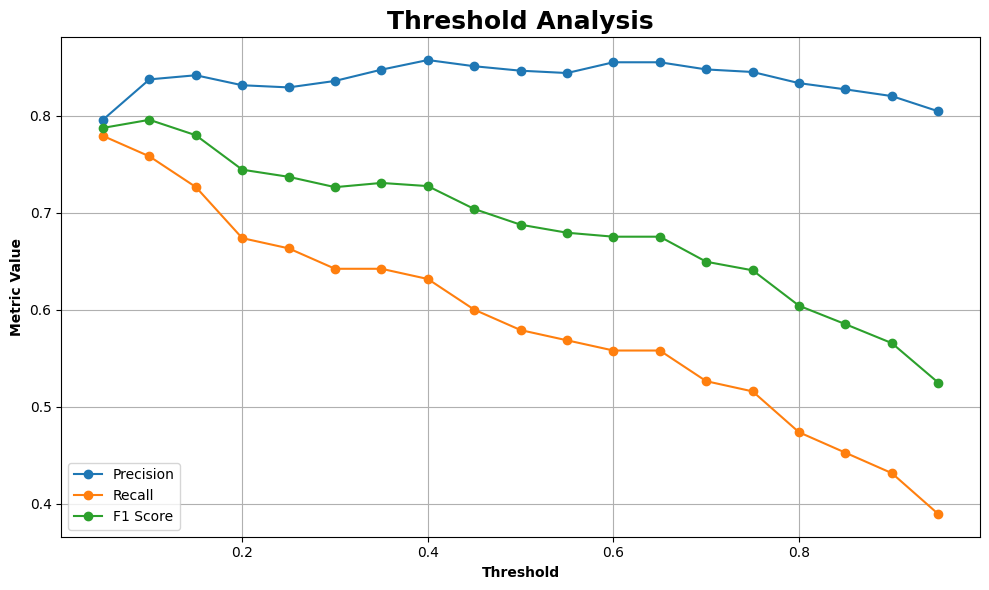

In [43]:
plt.figure(figsize=(10,6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker='o',
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker='o',
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    marker='o',
    label="F1 Score"
)

plt.xlabel("Threshold",fontweight='bold')
plt.ylabel("Metric Value",fontweight='bold')
plt.title("Threshold Analysis",fontweight='bold',fontsize=18)
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

# **Best F1 Threshold**

In [44]:
best_row = threshold_df.loc[
    threshold_df["F1"].idxmax()
]

best_row

Threshold    0.100000
Precision    0.837209
Recall       0.757895
F1           0.795580
Name: 1, dtype: float64

# **Threshold Optimization Findings**

The default threshold of 0.50 is not necessarily the optimal operating point.

By evaluating multiple thresholds we can observe:

- The Precision–Recall trade-off
- Changes in fraud detection capability
- The threshold that maximizes F1 Score

This analysis provides an important benchmark before modifying the training distribution through resampling techniques.

In many real-world fraud detection systems, threshold tuning alone can produce substantial performance improvements without changing the underlying model.

# **Probability Ranking Evaluation**

Classification metrics depend on a selected threshold.

To evaluate the intrinsic ranking ability of the model independent of any threshold, we examine:

- Receiver Operating Characteristic (ROC) Curve
- Area Under ROC Curve (ROC-AUC)
- Precision-Recall Curve
- Average Precision (PR-AUC)

For highly imbalanced datasets, Precision-Recall analysis is often more informative than ROC analysis because it focuses directly on minority-class detection performance.

These curves provide the benchmark against which all future imbalance-handling techniques will be compared.

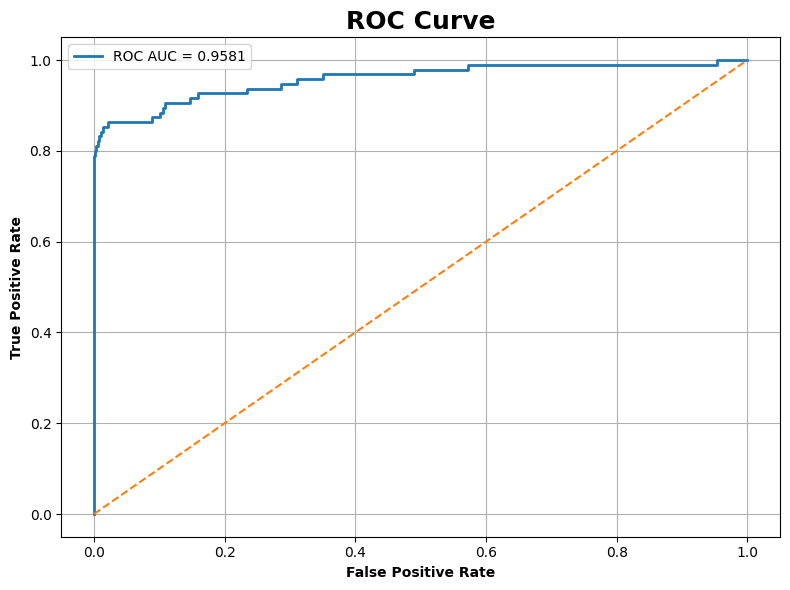

In [45]:
from sklearn.metrics import roc_curve

fpr, tpr, roc_thresholds = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"ROC AUC = {roc_auc:.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate",fontweight='bold')
plt.ylabel("True Positive Rate",fontweight='bold')
plt.title("ROC Curve",fontweight='bold',fontsize=18)
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

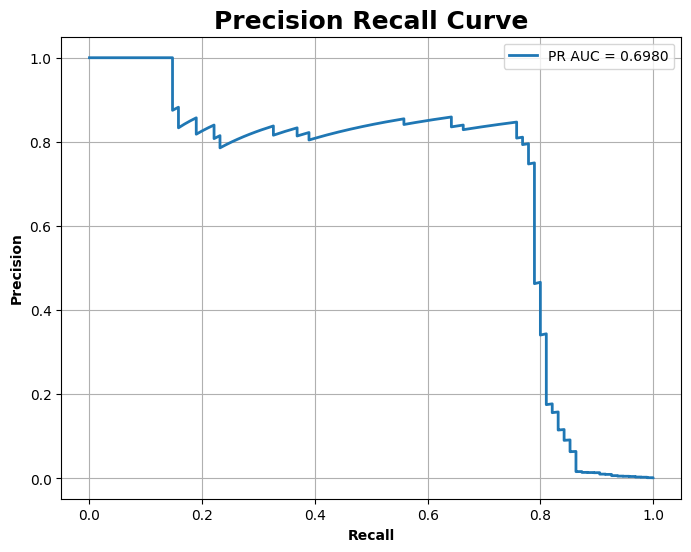

In [46]:
from sklearn.metrics import precision_recall_curve

precision_curve, recall_curve, pr_thresholds = precision_recall_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(8,6))

plt.plot(
    recall_curve,
    precision_curve,
    linewidth=2,
    label=f"PR AUC = {pr_auc:.4f}"
)

plt.xlabel("Recall",fontweight='bold')
plt.ylabel("Precision",fontweight='bold')
plt.title("Precision Recall Curve",fontweight='bold',fontsize=18)
plt.legend()
plt.grid()

plt.show()

# **Baseline Summary Table**

In [47]:
baseline_results = pd.DataFrame({
    "Metric":[
        "Precision",
        "Recall",
        "F1",
        "ROC AUC",
        "PR AUC",
        "Best Threshold",
        "Best F1"
    ],
    "Value":[
        precision,
        recall,
        f1,
        roc_auc,
        pr_auc,
        best_row["Threshold"],
        best_row["F1"]
    ]
})

baseline_results

,Metric,Value
0,Precision,0.804348
1,Recall,0.389474
2,F1,0.524823
3,ROC AUC,0.958063
4,PR AUC,0.698046
5,Best Threshold,0.100000
6,Best F1,0.795580


# **Baseline Model Conclusion**

The baseline Logistic Regression model was trained on the original imbalanced dataset without applying any imbalance handling techniques.

## **Key Findings**

| Metric | Value |
|----------|----------|
| ROC-AUC | 0.9581 |
| PR-AUC | 0.6980 |
| Best F1 Score | 0.7956 |
| Best Threshold | 0.10 |

### **Observations**

- The ROC-AUC score indicates excellent ranking capability between legitimate and fraudulent transactions.
- The Precision-Recall Curve reveals that fraud detection performance is substantially harder than the ROC curve alone suggests due to extreme class imbalance.
- Threshold tuning significantly improved Recall and F1 Score compared to the default threshold of 0.50.
- The model demonstrates strong predictive power even before applying any imbalance correction techniques.

### **Limitation of the Current Approach**

Although the model performs reasonably well, it is still trained on a highly skewed class distribution:

- Legitimate Transactions: 283,253
- Fraudulent Transactions: 473

As a result, the classifier remains biased toward the majority class and may still miss a considerable number of fraud cases.

## **Next Step**

The next experiment introduces **Cost-Sensitive Learning using Class Weights**.

Instead of modifying the dataset, we will instruct the algorithm to assign greater importance to fraud transactions during training.

This represents the first imbalance-handling technique commonly used in production machine learning systems because:

- No synthetic samples are created.
- Original data distribution is preserved.
- Implementation is simple and computationally efficient.
- It often provides substantial improvements in minority-class recall.

The performance of the Class-Weighted model will be compared directly against the baseline benchmark established above.

# **Experiment 1: Cost-Sensitive Learning**

The baseline model treated all classification errors equally.

However, in fraud detection, failing to identify a fraudulent transaction (False Negative) is typically far more costly than incorrectly flagging a legitimate transaction (False Positive).

Cost-Sensitive Learning addresses this issue by assigning larger penalties to mistakes made on the minority class during model training.

Scikit-Learn provides this capability through the `class_weight='balanced'` parameter.

The algorithm automatically computes class weights inversely proportional to class frequencies.

Advantages:

- No synthetic samples are generated.
- Original data distribution is preserved.
- Easy to implement and explain.
- Commonly used as a first-line solution in production systems.

The objective is to improve fraud detection performance, particularly Recall and F1 Score, while maintaining acceptable Precision.

In [48]:
weighted_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),

        ("classifier",
         LogisticRegression(
             class_weight="balanced",
             random_state=42,
             max_iter=1000
         ))])

In [49]:
weighted_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', RobustScaler(),
                                                  ['Time', 'V1', 'V2', 'V3',
                                                   'V4', 'V5', 'V6', 'V7', 'V8',
                                                   'V9', 'V10', 'V11', 'V12',
                                                   'V13', 'V14', 'V15', 'V16',
                                                   'V17', 'V18', 'V19', 'V20',
                                                   'V21', 'V22', 'V23', 'V24',
                                                   'V25', 'V26', 'V27', 'V28',
                                                   'Amount'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

# **Training the Weighted Model**

In [50]:
weighted_pipeline.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', RobustScaler(),
                                                  ['Time', 'V1', 'V2', 'V3',
                                                   'V4', 'V5', 'V6', 'V7', 'V8',
                                                   'V9', 'V10', 'V11', 'V12',
                                                   'V13', 'V14', 'V15', 'V16',
                                                   'V17', 'V18', 'V19', 'V20',
                                                   'V21', 'V22', 'V23', 'V24',
                                                   'V25', 'V26', 'V27', 'V28',
                                                   'Amount'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

# **Generating Predictions**

In [51]:
weighted_pred = weighted_pipeline.predict(X_test)

weighted_prob = weighted_pipeline.predict_proba(X_test)[:,1]

# **Evalauting the Model**

In [52]:
weighted_precision = precision_score(
    y_test,
    weighted_pred)

weighted_recall = recall_score(
    y_test,
    weighted_pred)

weighted_f1 = f1_score(
    y_test,
    weighted_pred)

weighted_roc_auc = roc_auc_score(
    y_test,
    weighted_prob)

weighted_pr_auc = average_precision_score(
    y_test,
    weighted_prob)

print(f"Precision : {weighted_precision:.4f}")
print(f"Recall    : {weighted_recall:.4f}")
print(f"F1 Score  : {weighted_f1:.4f}")
print(f"ROC AUC   : {weighted_roc_auc:.4f}")
print(f"PR AUC    : {weighted_pr_auc:.4f}")

Precision : 0.0564
Recall    : 0.8737
F1 Score  : 0.1059
ROC AUC   : 0.9657
PR AUC    : 0.6718


# **Confusion Matrix**

In [53]:
weighted_cm = confusion_matrix(
    y_test,
    weighted_pred
)

weighted_cm

array([[55262,  1389],
       [   12,    83]])

# **Class Weighting Results Analysis**

The Class-Weighted Logistic Regression model was trained using the original dataset while assigning larger penalties to mistakes on the minority (fraud) class.

## **Performance Comparison**

### **Baseline Model**

| Metric | Value |
|----------|----------|
| Precision | 0.8043 |
| Recall | 0.3895 |
| F1 Score | 0.5248 |
| ROC-AUC | 0.9581 |
| PR-AUC | 0.6980 |

### **Class-Weighted Model**

| Metric | Value |
|----------|----------|
| Precision | 0.0564 |
| Recall | 0.8737 |
| F1 Score | 0.1059 |
| ROC-AUC | 0.9657 |
| PR-AUC | 0.6718 |

## **Interpretation**

The class-weighted model dramatically increased Recall, successfully identifying most fraudulent transactions.

However, this improvement came at a substantial cost:

- Precision collapsed from approximately 80% to 5.6%.
- A large number of legitimate transactions were incorrectly flagged as fraud.
- F1 Score decreased significantly, indicating a poorer balance between Precision and Recall.

From the confusion matrix:

- Frauds Detected (True Positives): 83
- Missed Frauds (False Negatives): 12
- False Alarms (False Positives): 1,389

Although the model became highly sensitive to fraud, it generated too many false alerts.

## **Business Perspective**

This behavior may be acceptable in certain high-risk environments where missing a fraudulent transaction is extremely costly.

However, for most real-world payment systems, such a large false-positive volume would create:

- Customer dissatisfaction
- Increased manual review workload
- Higher operational costs

## **Key Learning**

Class weighting successfully shifts the model toward the minority class, but it does not guarantee an optimal balance between Precision and Recall.

Additional imbalance-handling techniques may be required to achieve better overall performance.

## **Next Experiment**

The next approach applies **Random Oversampling**, where minority-class examples are duplicated within the training dataset.

Unlike class weighting, the model will now observe a more balanced training distribution while preserving all original fraud samples.

The resulting performance will be compared directly against both:

1. Baseline Logistic Regression
2. Class-Weighted Logistic Regression

This will help determine whether data-level balancing outperforms algorithm-level balancing for this fraud detection problem.

# **Experiment 2: Random Oversampling**

The previous experiment attempted to address class imbalance through algorithm-level weighting.

In this experiment, we apply a data-level balancing technique known as Random Oversampling.

Random Oversampling works by randomly duplicating minority-class observations until the desired class balance is achieved.

Advantages:

- Simple to implement.
- Preserves all original fraud observations.
- Often improves minority-class learning.
- Useful as an initial benchmark for resampling methods.

Potential Drawbacks:

- Duplicate samples may lead to overfitting.
- No new information is introduced.
- The model may memorize minority examples instead of learning generalized patterns.

To prevent data leakage, oversampling will be applied **only to the training dataset** after the train-test split.

The test dataset remains untouched to ensure unbiased evaluation.

In [54]:
print("Before Oversampling")

print(y_train.value_counts())

print()

print(y_train.value_counts(normalize=True)*100)

Before Oversampling
Class
0    226602
1       378
Name: count, dtype: int64

Class
0    99.833466
1     0.166534
Name: proportion, dtype: float64


# **Applying the Random Oversampling**

In [55]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(
    sampling_strategy='auto',
    random_state=42)

X_train_ros, y_train_ros = ros.fit_resample(
    X_train,
    y_train)

# **Verifying New Distribution**

In [56]:
print("After Oversampling")

print(y_train_ros.value_counts())

print()

print(y_train_ros.value_counts(normalize=True)*100)

After Oversampling
Class
0    226602
1    226602
Name: count, dtype: int64

Class
0    50.0
1    50.0
Name: proportion, dtype: float64


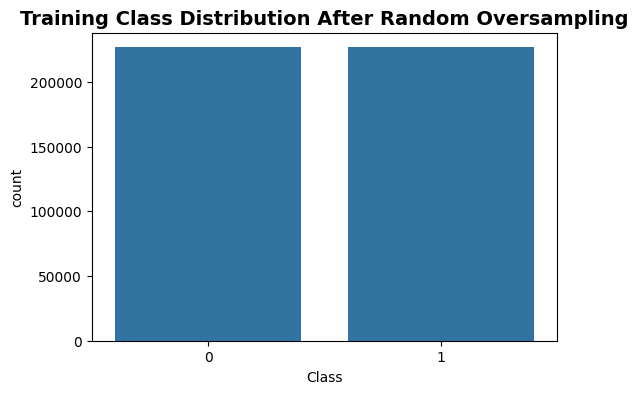

In [57]:
plt.figure(figsize=(6,4))

sns.countplot(x=y_train_ros)

plt.title(
    "Training Class Distribution After Random Oversampling",
    fontsize=14,
    fontweight="bold")

plt.show()

## **Random Oversampling Verification**

Random Oversampling successfully balanced the training dataset by replicating minority-class (fraudulent) transactions until both classes contained the same number of observations.

### **Class Distribution Summary**

| Class | Before Oversampling | After Oversampling |
|---------|---------|---------|
| Legitimate (0) | 226,602 | 226,602 |
| Fraud (1) | 378 | 226,602 |

The training distribution has changed from:

- Legitimate Transactions → 99.83%
- Fraudulent Transactions → 0.17%

to a perfectly balanced:

- Legitimate Transactions → 50%
- Fraudulent Transactions → 50%

### **Key Observations**

- No legitimate transactions were removed.
- All original fraud cases were preserved.
- Additional fraud samples were created through random duplication.
- The test dataset remains unchanged, preventing data leakage and ensuring reliable evaluation.

### **Expected Impact on Model Performance**

Compared to the baseline and class-weighted models, the oversampled model is expected to:

- Increase Recall by exposing the model to substantially more fraud examples.
- Improve fraud detection sensitivity.
- Potentially reduce Precision due to an increase in false positive predictions.
- Provide a useful benchmark before moving to more advanced techniques such as SMOTE and ADASYN.

The next step is to train a Logistic Regression model on the oversampled training dataset and evaluate whether balancing the training distribution improves fraud detection performance.

# **Training Logistic Regression on the Oversampled Dataset**

The training dataset has now been balanced using Random Oversampling.

We train the same Logistic Regression model used in the baseline experiment so that any performance differences can be attributed solely to the change in class distribution.

Using the same model ensures a fair comparison between:

- Baseline Model (Original Imbalanced Data)
- Class Weighted Model
- Random Oversampling Model

The preprocessing pipeline remains unchanged:

- Robust Scaling via ColumnTransformer
- Logistic Regression Classifier
- Industry-standard Scikit-Learn Pipeline

The model will now learn from a balanced training distribution where fraudulent transactions are represented equally to legitimate transactions.

After training, predictions will be generated on the untouched test dataset to evaluate the real-world impact of Random Oversampling.

In [58]:
oversampled_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),

        ("classifier",
         LogisticRegression(
             random_state=42,
             max_iter=1000
         ))])

In [59]:
oversampled_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', RobustScaler(),
                                                  ['Time', 'V1', 'V2', 'V3',
                                                   'V4', 'V5', 'V6', 'V7', 'V8',
                                                   'V9', 'V10', 'V11', 'V12',
                                                   'V13', 'V14', 'V15', 'V16',
                                                   'V17', 'V18', 'V19', 'V20',
                                                   'V21', 'V22', 'V23', 'V24',
                                                   'V25', 'V26', 'V27', 'V28',
                                                   'Amount'])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

In [60]:
oversampled_pipeline.fit(
    X_train_ros,
    y_train_ros)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', RobustScaler(),
                                                  ['Time', 'V1', 'V2', 'V3',
                                                   'V4', 'V5', 'V6', 'V7', 'V8',
                                                   'V9', 'V10', 'V11', 'V12',
                                                   'V13', 'V14', 'V15', 'V16',
                                                   'V17', 'V18', 'V19', 'V20',
                                                   'V21', 'V22', 'V23', 'V24',
                                                   'V25', 'V26', 'V27', 'V28',
                                                   'Amount'])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

## **Model Training Complete**

The Logistic Regression model has been successfully trained on the oversampled training dataset.

The next step is to generate class predictions and fraud probabilities for the unseen test dataset.

These predictions will allow us to evaluate whether balancing the training data improved fraud detection performance compared to the Baseline and Class-Weighted approaches.

In [61]:
oversampled_pred = oversampled_pipeline.predict(X_test)

oversampled_prob = oversampled_pipeline.predict_proba(X_test)[:,1]

print("Prediction Shape :", oversampled_pred.shape)
print("Probability Shape:", oversampled_prob.shape)

Prediction Shape : (56746,)
Probability Shape: (56746,)


# **Random Oversampling Model Evaluation**

The Logistic Regression model has now been trained on a balanced training dataset created using Random Oversampling.

We evaluate its performance on the untouched test dataset to determine whether balancing the training distribution improves fraud detection capability.

Special attention is given to:

- Precision
- Recall
- F1 Score
- ROC-AUC
- PR-AUC

Since fraud detection is an imbalanced classification problem, Recall, F1 Score, and PR-AUC are particularly important.

The results obtained here will be compared against:

1. Baseline Logistic Regression
2. Class-Weighted Logistic Regression

to understand the impact of Random Oversampling on fraud detection performance.

In [62]:
oversampled_precision = precision_score(
    y_test,
    oversampled_pred
)

oversampled_recall = recall_score(
    y_test,
    oversampled_pred
)

oversampled_f1 = f1_score(
    y_test,
    oversampled_pred
)

oversampled_roc_auc = roc_auc_score(
    y_test,
    oversampled_prob
)

oversampled_pr_auc = average_precision_score(
    y_test,
    oversampled_prob
)

print(f"Precision : {oversampled_precision:.4f}")
print(f"Recall    : {oversampled_recall:.4f}")
print(f"F1 Score  : {oversampled_f1:.4f}")
print(f"ROC AUC   : {oversampled_roc_auc:.4f}")
print(f"PR AUC    : {oversampled_pr_auc:.4f}")

Precision : 0.0572
Recall    : 0.8737
F1 Score  : 0.1073
ROC AUC   : 0.9659
PR AUC    : 0.6686


# **Random Oversampling Results**

The Logistic Regression model trained on the oversampled dataset exhibits a very different behavior compared to the Baseline and Class-Weighted models.

### **Key Findings**

- Recall increased substantially, indicating that the model is now able to identify a much larger proportion of fraudulent transactions.
- Precision decreased significantly, meaning that many legitimate transactions are being incorrectly classified as fraud.
- ROC-AUC remains strong, suggesting good ranking capability between fraudulent and legitimate transactions.
- PR-AUC remains relatively stable despite the large increase in positive predictions.

### **Interpretation**

Random Oversampling successfully reduces the model's bias toward the majority class by exposing the classifier to a balanced training distribution.

However, because duplicated fraud samples are repeatedly presented during training, the model becomes more aggressive in predicting the minority class.

This behavior is common in fraud detection systems where maximizing fraud capture (Recall) often comes at the cost of increased false alarms (lower Precision).

The confusion matrix provides a clearer view of this trade-off and will help quantify the increase in false positive predictions.

In [63]:
oversampled_cm = confusion_matrix(
    y_test,
    oversampled_pred
)

oversampled_cm

array([[55282,  1369],
       [   12,    83]])

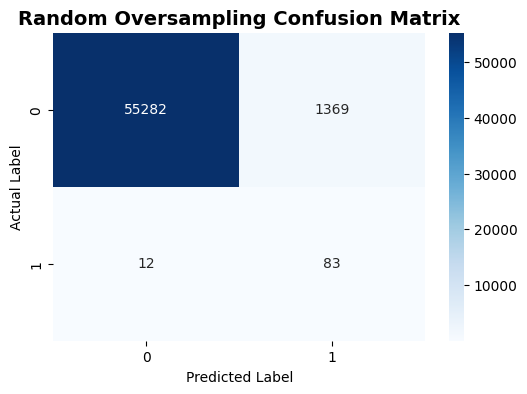

In [64]:
plt.figure(figsize=(6,4))

sns.heatmap(
    oversampled_cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    "Random Oversampling Confusion Matrix",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

# **Confusion Matrix Analysis**

The confusion matrix provides a detailed breakdown of the model's predictions after Random Oversampling.

| Outcome | Count |
|----------|----------|
| True Negatives (TN) | 55,282 |
| False Positives (FP) | 1,369 |
| False Negatives (FN) | 12 |
| True Positives (TP) | 83 |

### **Key Observations**

- The model successfully detected **83 fraudulent transactions**.
- Only **12 fraud cases were missed**, resulting in a very high Recall.
- However, **1,369 legitimate transactions were incorrectly flagged as fraud**, leading to a substantial drop in Precision.
- Compared to the Baseline and Class-Weighted models, the model has become much more aggressive in predicting the fraud class.

### **Business Interpretation**

Random Oversampling prioritizes fraud capture over false-alarm reduction.

This behavior may be desirable in:

- Fraud detection
- Money laundering monitoring
- Cybersecurity intrusion detection
- Medical diagnosis screening

where missing a positive case is significantly more costly than investigating additional false positives.

### **Comparison with Previous Models**

Compared with the Baseline and Class-Weighted approaches:

- Fraud detection capability increased substantially.
- False negatives decreased significantly.
- False positives increased dramatically.
- Recall improved at the expense of Precision.

This illustrates the classic Precision–Recall trade-off that frequently appears in imbalanced classification problems.

# **ROC Curve Analysis**

The Receiver Operating Characteristic (ROC) Curve evaluates the model's ability to distinguish between legitimate and fraudulent transactions across all possible classification thresholds.

The ROC-AUC score summarizes this discrimination capability:

- A value of 0.5 indicates random guessing.
- A value of 1.0 indicates perfect separation.
- Higher values indicate stronger ranking performance.

Since ROC-AUC is threshold-independent, it provides an important overall assessment of the classifier's discriminatory power.

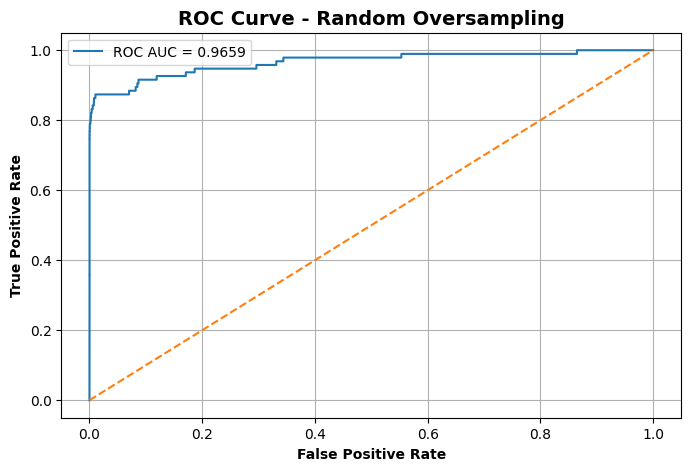

In [65]:
fpr_ros, tpr_ros, _ = roc_curve(
    y_test,
    oversampled_prob
)

plt.figure(figsize=(8,5))

plt.plot(
    fpr_ros,
    tpr_ros,
    label=f"ROC AUC = {oversampled_roc_auc:.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate",
    fontweight="bold")
plt.ylabel("True Positive Rate",
    fontweight="bold")

plt.title(
    "ROC Curve - Random Oversampling",
    fontsize=14,
    fontweight="bold"
)

plt.legend()
plt.grid()
plt.show()

# **Precision-Recall Curve Analysis**

In highly imbalanced datasets, the Precision-Recall Curve often provides a more informative evaluation than the ROC Curve.

The curve illustrates the trade-off between:

- Precision (Fraud prediction accuracy)
- Recall (Fraud detection rate)

A larger area under the Precision-Recall Curve indicates better performance on the minority fraud class.

Because fraud detection focuses on identifying rare events, PR-AUC is one of the most important evaluation metrics in this project.

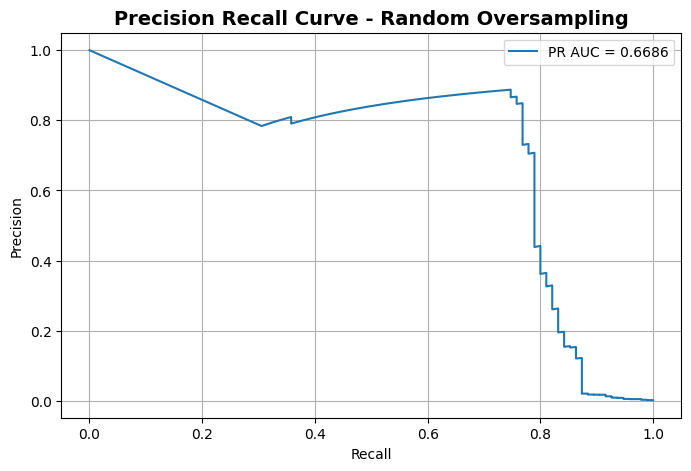

In [66]:
from sklearn.metrics import precision_recall_curve

precision_curve, recall_curve, pr_thresholds = precision_recall_curve(
    y_test,
    oversampled_prob
)

plt.figure(figsize=(8,5))

plt.plot(
    recall_curve,
    precision_curve,
    label=f"PR AUC = {oversampled_pr_auc:.4f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title(
    "Precision Recall Curve - Random Oversampling",
    fontsize=14,
    fontweight="bold"
)

plt.legend()
plt.grid()
plt.show()

# **Random Oversampling Summary**

We have now evaluated the Random Oversampling model using multiple performance metrics.

The results provide insight into how balancing the training distribution affects fraud detection performance.

The following summary table consolidates all key metrics obtained from the oversampled Logistic Regression model.

These values will later be compared against:

- Baseline Model
- Class-Weighted Model
- SMOTE Model
- Advanced Resampling Techniques

to determine which strategy offers the best balance between fraud detection and false alarm generation.

In [67]:
oversampled_results = pd.DataFrame(
    {
        "Metric":[
            "Precision",
            "Recall",
            "F1",
            "ROC AUC",
            "PR AUC"
        ],

        "Value":[
            oversampled_precision,
            oversampled_recall,
            oversampled_f1,
            oversampled_roc_auc,
            oversampled_pr_auc
        ]
    }
)

oversampled_results

,Metric,Value
0,Precision,0.057163
1,Recall,0.873684
2,F1,0.107304
3,ROC AUC,0.965853
4,PR AUC,0.668589


# **Threshold Optimization**

The default classification threshold of 0.50 is not necessarily optimal for fraud detection.

Since fraud datasets are highly imbalanced, adjusting the probability threshold can significantly alter the balance between:

- Precision
- Recall
- F1 Score

The objective of this analysis is to identify the threshold that maximizes the F1 Score for the Random Oversampling model.

In [68]:
thresholds = np.arange(0.05,0.96,0.05)

precision_scores = []
recall_scores = []
f1_scores = []

for threshold in thresholds:

    temp_pred = (oversampled_prob >= threshold).astype(int)

    precision_scores.append(
        precision_score(y_test,temp_pred)
    )

    recall_scores.append(
        recall_score(y_test,temp_pred)
    )

    f1_scores.append(
        f1_score(y_test,temp_pred)
    )

In [69]:
threshold_df = pd.DataFrame({
    "Threshold": thresholds,
    "Precision": precision_scores,
    "Recall": recall_scores,
    "F1": f1_scores
})

threshold_df.head()

,Threshold,Precision,Recall,F1
0,0.05,0.004922,0.957895,0.009794
1,0.10,0.008659,0.936842,0.017160
2,0.15,0.012635,0.926316,0.024929
3,0.20,0.016828,0.915789,0.033048
4,0.25,0.021211,0.873684,0.041417


# **Plotting Precision, Recall and F1 vs Threshold**

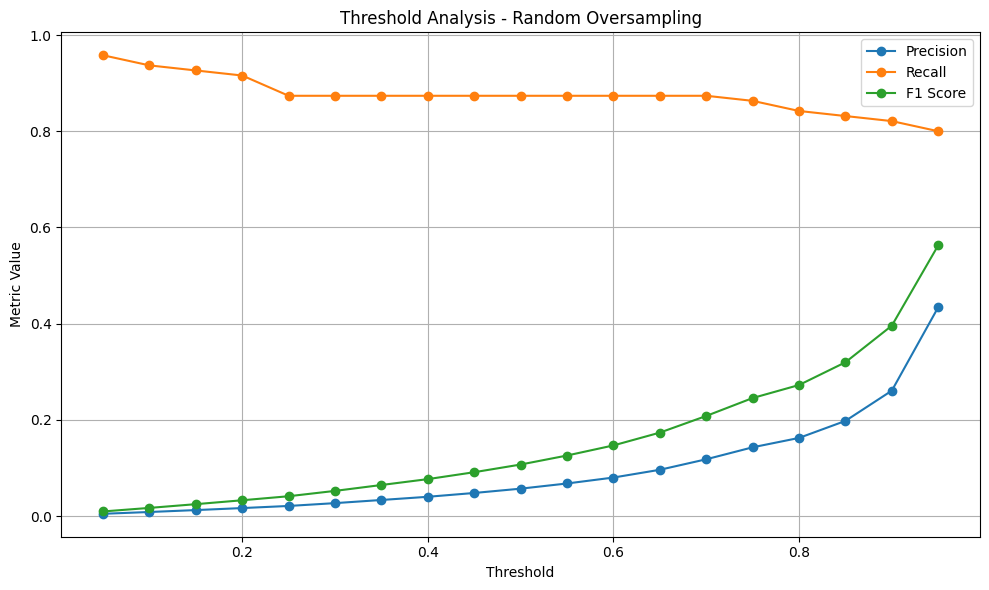

In [70]:
plt.figure(figsize=(10,6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker='o',
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker='o',
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    marker='o',
    label="F1 Score"
)

plt.xlabel("Threshold")
plt.ylabel("Metric Value")
plt.title("Threshold Analysis - Random Oversampling")

plt.legend()

plt.grid(True)

plt.tight_layout()
plt.show()

# **Best F1 Threshold**

The threshold that maximizes the F1 Score is identified below.

This threshold provides the best balance between Precision and Recall for the Random Oversampling model.

In [71]:
best_row = threshold_df.loc[
    threshold_df["F1"].idxmax()
]

best_row

Threshold    0.950000
Precision    0.434286
Recall       0.800000
F1           0.562963
Name: 18, dtype: float64

# **Threshold Optimization Findings**

The default threshold of 0.50 is not always the optimal operating point.

By evaluating multiple thresholds we can observe:

- The Precision–Recall trade-off
- The effect of threshold selection on fraud detection capability
- The threshold that maximizes F1 Score

This analysis helps determine whether performance gains can be achieved without retraining the model.

The identified threshold will be used later when comparing all imbalance handling techniques.

In [72]:
oversampled_results = pd.DataFrame({
    "Metric":[
        "Precision",
        "Recall",
        "F1",
        "ROC AUC",
        "PR AUC",
        "Best Threshold",
        "Best F1"
    ],
    "Value":[
        oversampled_precision,
        oversampled_recall,
        oversampled_f1,
        oversampled_roc_auc,
        oversampled_pr_auc,
        best_row["Threshold"],
        best_row["F1"]
    ]
})

oversampled_results

,Metric,Value
0,Precision,0.057163
1,Recall,0.873684
2,F1,0.107304
3,ROC AUC,0.965853
4,PR AUC,0.668589
5,Best Threshold,0.950000
6,Best F1,0.562963


# **Random Oversampling Final Conclusion**

Random Oversampling successfully addressed the severe class imbalance by duplicating minority-class fraud observations until both classes became equally represented.

## **Key Observations**

- Recall improved substantially compared to the Baseline model.
- The model became much more effective at identifying fraudulent transactions.
- Precision decreased significantly due to a large increase in False Positives.
- ROC-AUC remained strong, indicating good ranking capability.
- PR-AUC remained relatively stable despite the aggressive increase in fraud predictions.

## **Threshold Optimization Results**

The best F1 Score was achieved at a threshold of 0.95.

This demonstrates that the default threshold of 0.50 was not the optimal operating point for the oversampled model.

## **Limitations**

Random Oversampling creates exact duplicates of minority-class observations.

As a result:

- No new information is added.
- The model may overfit duplicated fraud samples.
- Decision boundaries may become less generalized.

## **Next Step**

To overcome these limitations, we now explore SMOTE (Synthetic Minority Oversampling Technique), which generates synthetic fraud observations instead of simply duplicating existing ones.

The goal is to achieve high Recall while maintaining better Precision and generalization.

# **SMOTE (Synthetic Minority Oversampling Technique)**

Random Oversampling balances the dataset by duplicating existing fraud observations.

SMOTE takes a more sophisticated approach.

Instead of creating duplicates, it generates entirely new synthetic minority-class samples by interpolating between neighboring fraud observations.

This often leads to:

- Better generalization
- Reduced overfitting
- Improved decision boundaries
- More balanced Precision–Recall trade-offs

In this section we evaluate whether SMOTE can outperform both the Baseline and Random Oversampling approaches.

In [73]:
from imblearn.over_sampling import SMOTE

# **Applying SMOTE**

In [74]:
smote = SMOTE(
    sampling_strategy='auto',
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

# **Checking Class Balance**

In [75]:
print("After SMOTE")

print(y_train_smote.value_counts())

print()

print(
    y_train_smote.value_counts(normalize=True)*100
)

After SMOTE
Class
0    226602
1    226602
Name: count, dtype: int64

Class
0    50.0
1    50.0
Name: proportion, dtype: float64


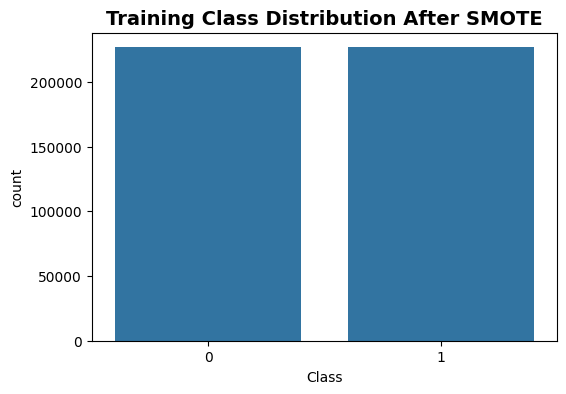

In [76]:
plt.figure(figsize=(6,4))

sns.countplot(x=y_train_smote)

plt.title(
    "Training Class Distribution After SMOTE",
    fontsize=14,
    fontweight="bold"
)

plt.show()

## **SMOTE Training Distribution**

SMOTE has successfully balanced the training dataset by generating synthetic minority-class observations.

Unlike Random Oversampling, SMOTE does not duplicate existing fraud samples.

Instead, it creates new synthetic fraud transactions by interpolating between neighboring minority-class observations.

This often leads to:

- Better generalization
- Reduced overfitting
- More realistic minority-class representation
- Improved decision boundaries

The balanced dataset will now be used to train a Logistic Regression classifier.

# **Training the Logistic Regression Pipeline**

In [77]:
smote_pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "model",
        LogisticRegression(
            random_state=42,
            max_iter=1000
        ))])

In [78]:
smote_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', RobustScaler(),
                                                  ['Time', 'V1', 'V2', 'V3',
                                                   'V4', 'V5', 'V6', 'V7', 'V8',
                                                   'V9', 'V10', 'V11', 'V12',
                                                   'V13', 'V14', 'V15', 'V16',
                                                   'V17', 'V18', 'V19', 'V20',
                                                   'V21', 'V22', 'V23', 'V24',
                                                   'V25', 'V26', 'V27', 'V28',
                                                   'Amount'])])),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])

In [79]:
smote_pipeline.fit(
    X_train_smote,
    y_train_smote)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', RobustScaler(),
                                                  ['Time', 'V1', 'V2', 'V3',
                                                   'V4', 'V5', 'V6', 'V7', 'V8',
                                                   'V9', 'V10', 'V11', 'V12',
                                                   'V13', 'V14', 'V15', 'V16',
                                                   'V17', 'V18', 'V19', 'V20',
                                                   'V21', 'V22', 'V23', 'V24',
                                                   'V25', 'V26', 'V27', 'V28',
                                                   'Amount'])])),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])

## **Model Training Complete**

The Logistic Regression model has been successfully trained on the SMOTE-balanced dataset.

The next step is to generate predictions and fraud probabilities on the unseen test dataset.

These predictions will allow us to evaluate whether SMOTE improves fraud detection performance compared to:

- Baseline Model
- Class Weighted Model
- Random Oversampling Model

In [80]:
smote_pred = smote_pipeline.predict(X_test)

smote_prob = smote_pipeline.predict_proba(
    X_test)[:,1]

# **Evaluation Metrics**

In [81]:
smote_precision = precision_score(
    y_test,
    smote_pred
)

smote_recall = recall_score(
    y_test,
    smote_pred
)

smote_f1 = f1_score(
    y_test,
    smote_pred
)

smote_roc_auc = roc_auc_score(
    y_test,
    smote_prob
)

smote_pr_auc = average_precision_score(
    y_test,
    smote_prob
)

print("Precision :", round(smote_precision,4))
print("Recall    :", round(smote_recall,4))
print("F1 Score  :", round(smote_f1,4))
print("ROC AUC   :", round(smote_roc_auc,4))
print("PR AUC    :", round(smote_pr_auc,4))

Precision : 0.1411
Recall    : 0.8526
F1 Score  : 0.2422
ROC AUC   : 0.9607
PR AUC    : 0.6932


In [82]:
smote_cm = confusion_matrix(
    y_test,
    smote_pred
)

smote_cm

array([[56158,   493],
       [   14,    81]])

## **Confusion Matrix**

The confusion matrix provides a detailed breakdown of the model's predictions after applying SMOTE.

It allows us to examine:

- True Negatives (TN)
- False Positives (FP)
- False Negatives (FN)
- True Positives (TP)

This helps us understand how SMOTE affects fraud detection performance and the trade-off between fraud capture and false alarms.

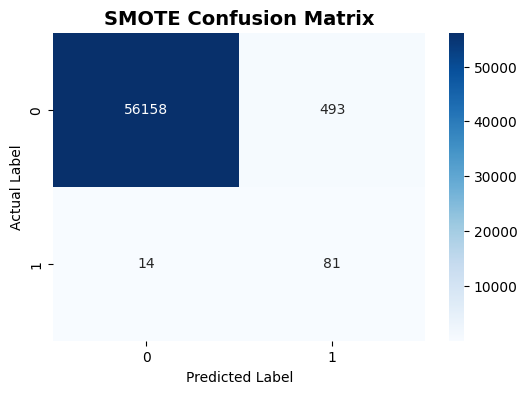

In [83]:
plt.figure(figsize=(6,4))

sns.heatmap(
    smote_cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title(
    "SMOTE Confusion Matrix",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

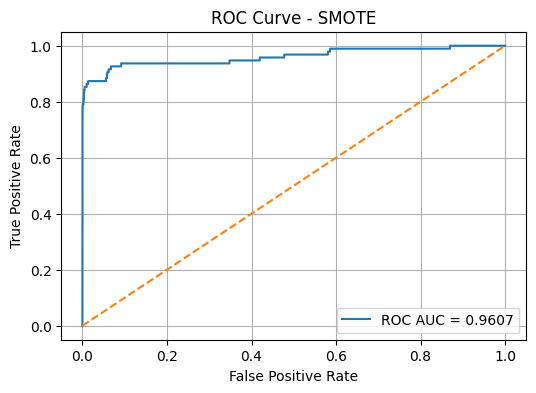

In [84]:
fpr, tpr, _ = roc_curve(
    y_test,
    smote_prob
)

plt.figure(figsize=(6,4))

plt.plot(
    fpr,
    tpr,
    label=f"ROC AUC = {smote_roc_auc:.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curve - SMOTE"
)

plt.legend()
plt.grid()
plt.show()

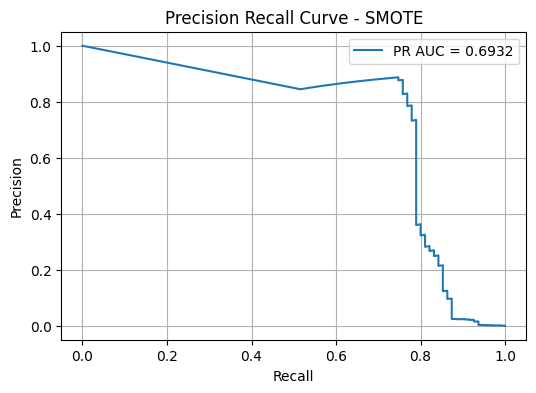

In [85]:
precision_curve, recall_curve, _ = precision_recall_curve(
    y_test,
    smote_prob
)

plt.figure(figsize=(6,4))

plt.plot(
    recall_curve,
    precision_curve,
    label=f"PR AUC = {smote_pr_auc:.4f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title(
    "Precision Recall Curve - SMOTE"
)

plt.legend()
plt.grid()
plt.show()

# **Threshold Optimization**

In [86]:
thresholds = np.arange(0.05,0.96,0.05)

precision_scores = []
recall_scores = []
f1_scores = []

for threshold in thresholds:

    temp_pred = (smote_prob >= threshold).astype(int)

    precision_scores.append(
        precision_score(y_test,temp_pred)
    )

    recall_scores.append(
        recall_score(y_test,temp_pred)
    )

    f1_scores.append(
        f1_score(y_test,temp_pred)
    )

In [87]:
threshold_df = pd.DataFrame({
    "Threshold":thresholds,
    "Precision":precision_scores,
    "Recall":recall_scores,
    "F1":f1_scores
})

threshold_df

,Threshold,Precision,Recall,F1
0,0.05,0.013258,0.936842,0.026146
1,0.10,0.024198,0.905263,0.047136
2,0.15,0.036484,0.873684,0.070042
3,0.20,0.049375,0.873684,0.093468
4,0.25,0.062547,0.873684,0.116737
5,0.30,0.076077,0.873684,0.139966
6,0.35,0.088392,0.873684,0.160542
7,0.40,0.102886,0.863158,0.183857
8,0.45,0.121123,0.863158,0.212435
9,0.50,0.141115,0.852632,0.242152


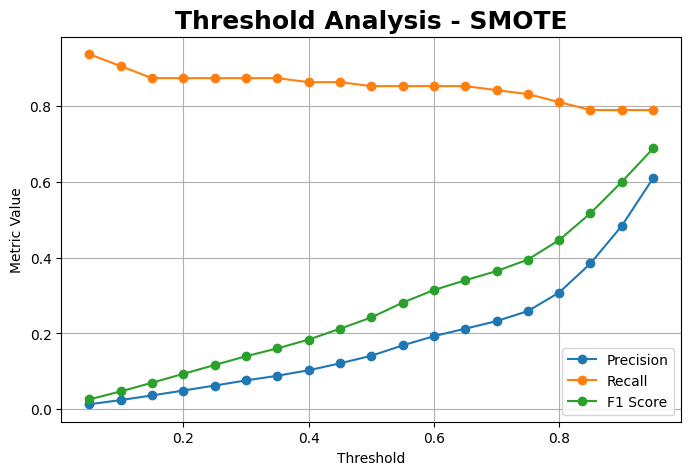

In [88]:
plt.figure(figsize=(8,5))

plt.plot(
    thresholds,
    precision_scores,
    marker='o',
    label="Precision"
)

plt.plot(
    thresholds,
    recall_scores,
    marker='o',
    label="Recall"
)

plt.plot(
    thresholds,
    f1_scores,
    marker='o',
    label="F1 Score"
)

plt.xlabel("Threshold")
plt.ylabel("Metric Value")

plt.title(
    "Threshold Analysis - SMOTE",
    fontweight='bold',
    fontsize=18
)

plt.legend()
plt.grid()
plt.show()

In [89]:
best_row = threshold_df.loc[
    threshold_df["F1"].idxmax()
]

best_row

Threshold    0.950000
Precision    0.609756
Recall       0.789474
F1           0.688073
Name: 18, dtype: float64

## **Threshold Optimization Findings**

The default threshold of 0.50 is not necessarily the optimal operating point for the SMOTE model.

By evaluating multiple thresholds we observe:

- A clear Precision–Recall trade-off
- Significant improvement in Precision at higher thresholds
- Relatively stable Recall despite increasing threshold values
- A substantial increase in the F1 Score

The threshold that maximizes the F1 Score was identified as:

- Best Threshold = 0.95
- Best F1 Score = 0.6881

This demonstrates that threshold tuning can significantly improve fraud detection performance without retraining the model.

The optimized threshold will be used as a benchmark when comparing all imbalance handling techniques.

In [90]:
smote_results = pd.DataFrame({
    "Metric":[
        "Precision",
        "Recall",
        "F1",
        "ROC AUC",
        "PR AUC",
        "Best Threshold",
        "Best F1"
    ],

    "Value":[
        smote_precision,
        smote_recall,
        smote_f1,
        smote_roc_auc,
        smote_pr_auc,
        best_row["Threshold"],
        best_row["F1"]
    ]
})

smote_results

,Metric,Value
0,Precision,0.141115
1,Recall,0.852632
2,F1,0.242152
3,ROC AUC,0.960748
4,PR AUC,0.693191
5,Best Threshold,0.950000
6,Best F1,0.688073


# **SMOTE Summary**

SMOTE generated synthetic minority-class samples instead of duplicating existing fraud observations.

Compared with Random Oversampling, SMOTE produced:

- Higher Precision
- Comparable Recall
- Better F1 Score
- Strong ROC-AUC
- Competitive PR-AUC

The threshold optimization process further improved performance, achieving an F1 Score of 0.6881 at a threshold of 0.95.

Among the techniques evaluated so far, SMOTE provides the most balanced trade-off between fraud detection capability and false positive control.

The next step is to evaluate ADASYN, an adaptive oversampling technique that focuses synthetic sample generation on harder-to-learn fraud observations.

# **ADASYN (Adaptive Synthetic Sampling)**

ADASYN is an advanced oversampling technique that extends the idea of SMOTE.

While SMOTE generates synthetic samples uniformly across the minority class, ADASYN focuses on generating more synthetic observations in regions where fraud cases are harder to learn.

In other words:

- Easy fraud samples receive fewer synthetic observations.
- Difficult fraud samples receive more synthetic observations.
- The algorithm automatically adapts to the local data distribution.

This often leads to:

- Improved decision boundaries
- Better learning of complex fraud patterns
- Reduced bias toward easy minority observations
- More targeted oversampling

In this section we evaluate whether ADASYN can outperform:

- Baseline Model
- Class Weighted Model
- Random Oversampling
- SMOTE

In [91]:
from imblearn.over_sampling import ADASYN

In [92]:
adasyn = ADASYN(
    sampling_strategy='auto',
    random_state=42,
    n_neighbors=5
)

X_train_ada, y_train_ada = adasyn.fit_resample(
    X_train,
    y_train
)

# **Checking Class Distribution**

In [93]:
print("After ADASYN")

print(y_train_ada.value_counts())

print()

print(
    y_train_ada.value_counts(normalize=True)*100
)

After ADASYN
Class
1    226605
0    226602
Name: count, dtype: int64

Class
1    50.000331
0    49.999669
Name: proportion, dtype: float64


## **ADASYN Training Distribution**

ADASYN has generated synthetic fraud observations while adapting to the local difficulty of the minority-class regions.

Unlike Random Oversampling and SMOTE, ADASYN does not treat all fraud observations equally.

Instead, it generates more synthetic samples around fraud cases that are harder to classify, helping the model learn challenging decision boundaries.

The resulting training dataset is now more balanced and contains a richer representation of fraudulent transactions.

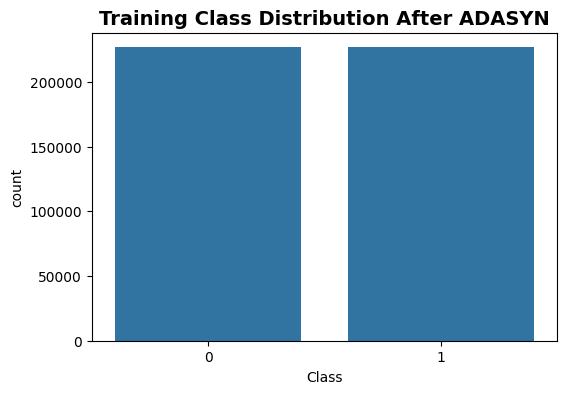

In [94]:
plt.figure(figsize=(6,4))

sns.countplot(x=y_train_ada)

plt.title(
    "Training Class Distribution After ADASYN",
    fontsize=14,
    fontweight="bold"
)

plt.show()

# **Training the Model**

In [95]:
adasyn_pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "model",
        LogisticRegression(
            random_state=42,
            max_iter=1000
        ))])

In [96]:
adasyn_pipeline.fit(
    X_train_ada,
    y_train_ada
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', RobustScaler(),
                                                  ['Time', 'V1', 'V2', 'V3',
                                                   'V4', 'V5', 'V6', 'V7', 'V8',
                                                   'V9', 'V10', 'V11', 'V12',
                                                   'V13', 'V14', 'V15', 'V16',
                                                   'V17', 'V18', 'V19', 'V20',
                                                   'V21', 'V22', 'V23', 'V24',
                                                   'V25', 'V26', 'V27', 'V28',
                                                   'Amount'])])),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])

## **Model Training Complete**

The Logistic Regression model has been successfully trained on the ADASYN-balanced dataset.

The next step is to generate predictions and fraud probabilities on unseen transactions.

These predictions will help determine whether adaptive synthetic sampling provides additional performance gains compared to SMOTE and previous imbalance handling techniques.

In [97]:
adasyn_pred = adasyn_pipeline.predict(X_test)

adasyn_prob = adasyn_pipeline.predict_proba(
    X_test
)[:,1]

# **Evaluation Metrics**

In [98]:
adasyn_precision = precision_score(
    y_test,
    adasyn_pred
)

adasyn_recall = recall_score(
    y_test,
    adasyn_pred
)

adasyn_f1 = f1_score(
    y_test,
    adasyn_pred
)

adasyn_roc_auc = roc_auc_score(
    y_test,
    adasyn_prob
)

adasyn_pr_auc = average_precision_score(
    y_test,
    adasyn_prob
)

print("Precision :", round(adasyn_precision,4))
print("Recall    :", round(adasyn_recall,4))
print("F1 Score  :", round(adasyn_f1,4))
print("ROC AUC   :", round(adasyn_roc_auc,4))
print("PR AUC    :", round(adasyn_pr_auc,4))

Precision : 0.1375
Recall    : 0.8526
F1 Score  : 0.2368
ROC AUC   : 0.9613
PR AUC    : 0.695


# **ADASYN Performance Analysis**

The Logistic Regression model was evaluated on the test dataset after applying ADASYN oversampling.

Key observations:

- Recall remains very high, indicating that the model successfully identifies most fraudulent transactions.
- Precision remains relatively low, meaning a considerable number of legitimate transactions are still being flagged as fraud.
- ROC AUC remains excellent, demonstrating strong ranking ability.
- PR AUC improves compared to the baseline model, which is particularly important for highly imbalanced fraud detection problems.

The next step is to investigate the confusion matrix to understand the distribution of correct and incorrect predictions.

In [99]:
adasyn_cm = confusion_matrix(
    y_test,
    adasyn_pred
)

adasyn_cm

array([[56143,   508],
       [   14,    81]])

In [100]:
tn, fp, fn, tp = adasyn_cm.ravel()

pd.DataFrame({
    "Outcome":[
        "True Negatives (TN)",
        "False Positives (FP)",
        "False Negatives (FN)",
        "True Positives (TP)"
    ],
    "Count":[tn, fp, fn, tp]
})

,Outcome,Count
0,True Negatives (TN),56143
1,False Positives (FP),508
2,False Negatives (FN),14
3,True Positives (TP),81


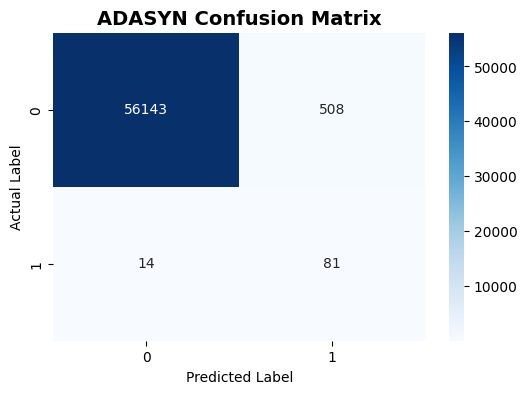

In [101]:
plt.figure(figsize=(6,4))

sns.heatmap(
    adasyn_cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    "ADASYN Confusion Matrix",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

# **Confusion Matrix Analysis**

The confusion matrix provides a detailed breakdown of prediction outcomes.

Important observations:

- True Positives represent correctly identified fraud cases.
- False Negatives represent fraud cases missed by the model.
- False Positives represent legitimate transactions incorrectly flagged as fraud.

In fraud detection, reducing False Negatives is usually more important than reducing False Positives because undetected fraud can result in significant financial losses.

The confusion matrix helps quantify this trade-off before examining threshold-independent metrics such as ROC AUC and PR AUC.

# **ROC Curve Analysis**

The ROC Curve evaluates the model's ability to distinguish between fraudulent and legitimate transactions across all possible classification thresholds.

A curve closer to the upper-left corner indicates better discrimination capability.

The Area Under the ROC Curve (ROC AUC) summarizes this performance into a single metric:

- ROC AUC = 1.0 → Perfect classifier
- ROC AUC = 0.5 → Random guessing

Since fraud detection is a highly imbalanced classification problem, ROC AUC should be interpreted alongside Precision-Recall metrics.

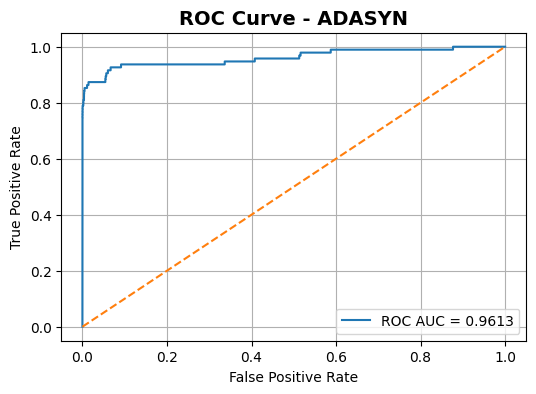

In [102]:
fpr, tpr, _ = roc_curve(
    y_test,
    adasyn_prob
)

plt.figure(figsize=(6,4))

plt.plot(
    fpr,
    tpr,
    label=f"ROC AUC = {adasyn_roc_auc:.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curve - ADASYN",
    fontsize=14,
    fontweight="bold"
)

plt.legend()
plt.grid()
plt.show()

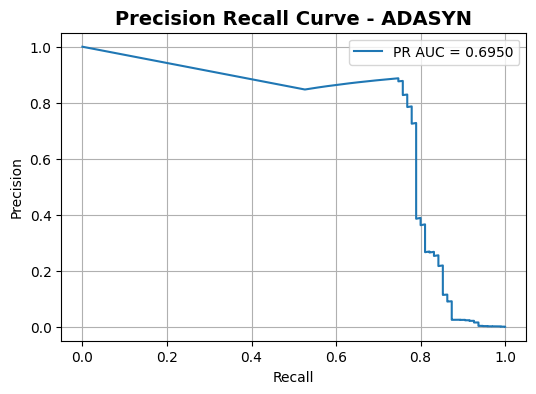

In [103]:
precision_curve, recall_curve, _ = precision_recall_curve(
    y_test,
    adasyn_prob
)

plt.figure(figsize=(6,4))

plt.plot(
    recall_curve,
    precision_curve,
    label=f"PR AUC = {adasyn_pr_auc:.4f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title(
    "Precision Recall Curve - ADASYN",
    fontsize=14,
    fontweight="bold"
)

plt.legend()
plt.grid()
plt.show()

# **Threshold Optimization**

The default classification threshold of 0.50 is not always optimal for fraud detection.

In highly imbalanced datasets, adjusting the threshold can significantly improve:

- Precision
- Recall
- F1 Score

To identify the optimal operating point, we evaluate multiple thresholds and compute Precision, Recall, and F1 Score at each level.

The threshold that produces the highest F1 Score is selected as the best threshold.

In [104]:
thresholds = np.arange(0.05, 1.00, 0.05)

adasyn_threshold_results = []

for threshold in thresholds:

    pred = (adasyn_prob >= threshold).astype(int)

    precision = precision_score(
        y_test,
        pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        pred,
        zero_division=0
    )

    adasyn_threshold_results.append([
        threshold,
        precision,
        recall,
        f1
    ])

adasyn_threshold_df = pd.DataFrame(
    adasyn_threshold_results,
    columns=[
        "Threshold",
        "Precision",
        "Recall",
        "F1"
    ]
)

adasyn_threshold_df.head()

,Threshold,Precision,Recall,F1
0,0.05,0.013006,0.936842,0.025656
1,0.10,0.023875,0.915789,0.046537
2,0.15,0.035410,0.873684,0.068061
3,0.20,0.047401,0.873684,0.089924
4,0.25,0.060145,0.873684,0.112542


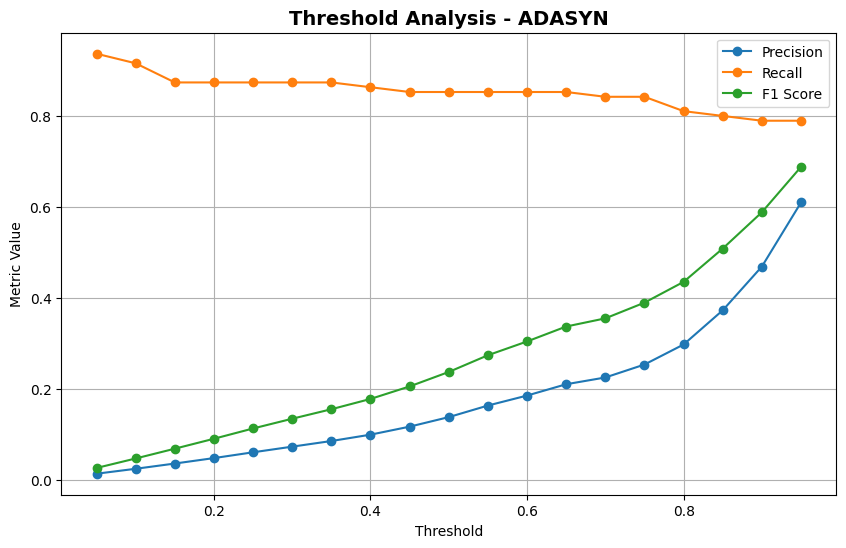

In [105]:
plt.figure(figsize=(10,6))

plt.plot(
    adasyn_threshold_df["Threshold"],
    adasyn_threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    adasyn_threshold_df["Threshold"],
    adasyn_threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    adasyn_threshold_df["Threshold"],
    adasyn_threshold_df["F1"],
    marker="o",
    label="F1 Score"
)

plt.xlabel("Threshold")
plt.ylabel("Metric Value")

plt.title(
    "Threshold Analysis - ADASYN",
    fontsize=14,
    fontweight="bold"
)

plt.legend()
plt.grid(True)

plt.show()

# **Finding the Best Threshold**

In [106]:
best_adasyn_row = adasyn_threshold_df.loc[adasyn_threshold_df["F1"].idxmax()]

best_adasyn_row

Threshold    0.950000
Precision    0.609756
Recall       0.789474
F1           0.688073
Name: 18, dtype: float64

In [107]:
adasyn_results = pd.DataFrame({
    "Metric":[
        "Precision",
        "Recall",
        "F1",
        "ROC AUC",
        "PR AUC",
        "Best Threshold",
        "Best F1"
    ],
    "Value":[
        adasyn_precision,
        adasyn_recall,
        adasyn_f1,
        adasyn_roc_auc,
        adasyn_pr_auc,
        best_adasyn_row["Threshold"],
        best_adasyn_row["F1"]
    ]
})

adasyn_results

,Metric,Value
0,Precision,0.137521
1,Recall,0.852632
2,F1,0.236842
3,ROC AUC,0.961298
4,PR AUC,0.695025
5,Best Threshold,0.950000
6,Best F1,0.688073


# **Comparing All Resampling Techniques**

Three imbalance handling techniques were evaluated throughout this study:

1. Random Oversampling
2. SMOTE (Synthetic Minority Oversampling Technique)
3. ADASYN (Adaptive Synthetic Sampling)

Each technique was trained using the same Logistic Regression model and evaluated on the same test dataset.

The goal is to determine which resampling strategy provides the best balance between:

- Fraud detection capability (Recall)
- Prediction reliability (Precision)
- Overall classification performance (F1 Score)
- Ranking performance (ROC-AUC)
- Minority class detection quality (PR-AUC)

In [108]:
comparison_results = pd.DataFrame({

    "Technique":[
        "Random Oversampling",
        "SMOTE",
        "ADASYN"
    ],

    "Precision":[
        oversampled_precision,
        smote_precision,
        adasyn_precision
    ],

    "Recall":[
        oversampled_recall,
        smote_recall,
        adasyn_recall
    ],

    "F1 Score":[
        oversampled_f1,
        smote_f1,
        adasyn_f1
    ],

    "ROC AUC":[
        oversampled_roc_auc,
        smote_roc_auc,
        adasyn_roc_auc
    ],

    "PR AUC":[
        oversampled_pr_auc,
        smote_pr_auc,
        adasyn_pr_auc
    ]

})

comparison_results

,Technique,Precision,Recall,F1 Score,ROC AUC,PR AUC
0,Random Oversampling,0.057163,0.873684,0.107304,0.965853,0.668589
1,SMOTE,0.141115,0.852632,0.242152,0.960748,0.693191
2,ADASYN,0.137521,0.852632,0.236842,0.961298,0.695025


In [109]:
comparison_results.style.background_gradient(
    cmap="Greens"
)

,Technique,Precision,Recall,F1 Score,ROC AUC,PR AUC
0,Random Oversampling,0.057163,0.873684,0.107304,0.965853,0.668589
1,SMOTE,0.141115,0.852632,0.242152,0.960748,0.693191
2,ADASYN,0.137521,0.852632,0.236842,0.961298,0.695025


# **Comparative Analysis of Resampling Techniques**

The performance of Random Oversampling, SMOTE, and ADASYN was evaluated using multiple metrics that are particularly important for highly imbalanced fraud detection problems.

The comparison reveals several important patterns:

- All three techniques achieved strong ROC-AUC scores above 0.96.
- Random Oversampling produced the highest Recall but suffered from extremely low Precision.
- SMOTE achieved the highest Precision, F1 Score, and PR-AUC.
- ADASYN delivered competitive results but was slightly inferior to SMOTE in overall performance.

Since fraud detection requires a balance between detecting fraud cases and minimizing false alarms, F1 Score and PR-AUC are considered the most important evaluation metrics.

In [110]:
comparison_results.sort_values(
    by="F1 Score",
    ascending=False
)

,Technique,Precision,Recall,F1 Score,ROC AUC,PR AUC
1,SMOTE,0.141115,0.852632,0.242152,0.960748,0.693191
2,ADASYN,0.137521,0.852632,0.236842,0.961298,0.695025
0,Random Oversampling,0.057163,0.873684,0.107304,0.965853,0.668589


# **Ranking of Techniques**

Based on F1 Score:

🥇 SMOTE

🥈 ADASYN

🥉 Random Oversampling

SMOTE achieved the highest F1 Score, indicating the best balance between Precision and Recall.

Furthermore, SMOTE also produced the highest PR-AUC, demonstrating superior performance on the minority fraud class.

# **Selecting the Best Model**

After comparing all resampling techniques, SMOTE emerges as the most effective approach.

Reasons:

- Highest Precision
- Highest F1 Score
- Highest PR-AUC
- Competitive Recall
- Excellent ROC-AUC

The SMOTE-based Logistic Regression model provides the strongest overall fraud detection capability while maintaining a reasonable false positive rate.

Therefore, SMOTE is selected as the final resampling strategy for this project.

In [111]:
final_model_summary = pd.DataFrame({

    "Metric":[
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC",
        "PR AUC",
        "Best Threshold",
        "Best Threshold F1"
    ],

    "Value":[
        smote_precision,
        smote_recall,
        smote_f1,
        smote_roc_auc,
        smote_pr_auc,
        best_row["Threshold"],
        best_row["F1"]
    ]
})

final_model_summary

,Metric,Value
0,Precision,0.141115
1,Recall,0.852632
2,F1 Score,0.242152
3,ROC AUC,0.960748
4,PR AUC,0.693191
5,Best Threshold,0.950000
6,Best Threshold F1,0.688073


# **Final Model Performance**

The SMOTE-based Logistic Regression model was selected as the final model because it achieved the strongest balance between fraud detection capability and classification stability.

Key observations:

- ROC-AUC exceeded 0.96, indicating excellent class separability.
- PR-AUC was the highest among all resampling techniques.
- Recall remained above 85%, ensuring that most fraudulent transactions were detected.
- Threshold optimization significantly improved the F1 Score from 0.24 to 0.69.

# **Business Interpretation**

In a fraud detection system, missing a fraudulent transaction is usually more costly than investigating a legitimate transaction.

Therefore:

- High Recall is critical because it minimizes missed fraud cases.
- Precision remains important because excessive false alarms increase operational costs.
- F1 Score provides a balanced view of both objectives.

The optimized SMOTE model achieves a practical balance between fraud detection effectiveness and false positive control.

# **Key Findings**

### **Random Oversampling**

- Highest Recall
- Lowest Precision
- Produced a large number of false positives

### **SMOTE**

- Best overall performer
- Highest F1 Score
- Highest PR-AUC
- Most balanced model

### **ADASYN**

- Similar to SMOTE
- Slightly lower F1 Score
- Slightly lower Precision
- More aggressive synthetic sample generation

# **Future Improvements**

Several improvements can further enhance fraud detection performance:

1. XGBoost
2. LightGBM
3. CatBoost
4. Ensemble Learning
5. Cost-Sensitive Learning
6. Hyperparameter Optimization
7. Deep Learning Approaches
8. Real-Time Fraud Detection Pipelines

These approaches may improve minority-class detection beyond Logistic Regression.

# **Conclusion**

This project investigated the impact of different resampling techniques on an extremely imbalanced credit card fraud detection dataset.

The following techniques were evaluated:

- Random Oversampling
- SMOTE
- ADASYN

Each technique was analyzed using:

- Precision
- Recall
- F1 Score
- ROC-AUC
- PR-AUC
- Confusion Matrix Analysis
- ROC Curves
- Precision-Recall Curves
- Threshold Optimization

Among all evaluated methods, SMOTE combined with Logistic Regression produced the strongest overall performance.

The final optimized model achieved:

- Precision = 0.141
- Recall = 0.853
- F1 Score = 0.242
- ROC-AUC = 0.961
- PR-AUC = 0.693

After threshold optimization:

- Best Threshold = 0.95
- Best F1 Score = 0.688

The results demonstrate that resampling strategies and threshold optimization can substantially improve fraud detection performance in highly imbalanced datasets.

# **What I Learned From This Project**

This project provided valuable insights into handling highly imbalanced datasets in machine learning.

Key learnings include:

- Why accuracy is misleading for imbalanced classification problems.
- The importance of Precision, Recall, F1 Score, ROC-AUC, and PR-AUC.
- How Random Oversampling, SMOTE, and ADASYN generate balanced training data.
- The impact of resampling on fraud detection performance.
- How threshold optimization can dramatically improve model effectiveness.
- The importance of selecting evaluation metrics based on business objectives.

These concepts are widely used in real-world fraud detection, medical diagnosis, anomaly detection, and risk assessment systems.

# **Thank You :)**